In [28]:
# ============================================================
# Notebook 03
# Finite-width Gaussian pulses and Liouvillian pulse operators
# ============================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import norm
from scipy.linalg import expm

np.set_printoptions(
    precision=6,
    suppress=True,
    linewidth=120,
)

print("NumPy version:", np.__version__)
print("Current directory:", Path.cwd())

NumPy version: 2.3.5
Current directory: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/notebooks


In [32]:
# ============================================================
# Import project code
# ============================================================

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dimer_model import build_dimer, stationary_state

print("Project imports successful.")

Project imports successful.


In [33]:
# ============================================================
# Build the coupled two-level-system model
# ============================================================

model = build_dimer()

hbar = model["hbar"]
d = model["d"]

H = model["H_S"]
mu = model["mu"]

L_super = model["L_super"]
V = model["V"]

I4 = model["I4"]
I16 = np.eye(d * d, dtype=complex)

print("Hilbert-space dimension:", d)
print("Liouville-space dimension:", d * d)
print("H shape:", H.shape)
print("mu shape:", mu.shape)
print("L shape:", L_super.shape)
print("V shape:", V.shape)

Hilbert-space dimension: 4
Liouville-space dimension: 16
H shape: (4, 4)
mu shape: (4, 4)
L shape: (16, 16)
V shape: (16, 16)


In [34]:
# ============================================================
# Initial states: prepared ground state and stationary state
# ============================================================

gg = model["gg"]

rho_g = np.outer(gg, gg.conj())
rho_ss = stationary_state(L_super, d)

rho_g_vec = rho_g.reshape(-1, order="F")
rho_ss_vec = rho_ss.reshape(-1, order="F")

drift_g = norm(L_super @ rho_g_vec)
drift_ss = norm(L_super @ rho_ss_vec)

print("rho_g:")
print(rho_g)

print("\nrho_ss:")
print(rho_ss)

print("\nTr(rho_g)  =", np.trace(rho_g))
print("Tr(rho_ss) =", np.trace(rho_ss))

print("\n||L rho_g||  =", drift_g)
print("||L rho_ss|| =", drift_ss)

rho_g:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

rho_ss:
[[ 0.911157+0.j -0.      -0.j  0.      +0.j  0.      +0.j]
 [-0.      +0.j  0.043388+0.j -0.      +0.j -0.      +0.j]
 [ 0.      -0.j -0.      -0.j  0.043388+0.j  0.      -0.j]
 [ 0.      +0.j -0.      -0.j  0.      +0.j  0.002066+0.j]]

Tr(rho_g)  = (1+0j)
Tr(rho_ss) = (1+0j)

||L rho_g||  = 0.006123724356957946
||L rho_ss|| = 1.7414670990977083e-18


In [35]:
# ============================================================
# Raising and lowering dipole superoperators
# ============================================================

mu_up = model["sigma_a_plus"] + model["sigma_b_plus"]
mu_down = model["sigma_a_minus"] + model["sigma_b_minus"]

V_up = 1j / hbar * (
    np.kron(I4, mu_up)
    - np.kron(mu_up.T, I4)
)

V_down = 1j / hbar * (
    np.kron(I4, mu_down)
    - np.kron(mu_down.T, I4)
)

print("V_up shape:", V_up.shape)
print("V_down shape:", V_down.shape)

print("\n||V - (V_up + V_down)|| =",
      norm(V - (V_up + V_down)))

V_up shape: (16, 16)
V_down shape: (16, 16)

||V - (V_up + V_down)|| = 0.0


In [36]:
# ============================================================
# Record model parameters
# ============================================================

print("omega_a =", model["omega_a"])
print("omega_b =", model["omega_b"])
print("J       =", model["J"])

print("gamma_a =", model["gamma_a"])
print("gamma_b =", model["gamma_b"])

print("nbar_a  =", model["nbar_a"])
print("nbar_b  =", model["nbar_b"])

omega_a = 1.0
omega_b = 1.2
J       = 0.1
gamma_a = 0.05
gamma_b = 0.05
nbar_a  = 0.05
nbar_b  = 0.05


In [37]:
# ============================================================
# Spectroscopic frequencies and resolvent parameters
# ============================================================

omega_a = model["omega_a"]
omega_b = model["omega_b"]
J = model["J"]

omega_minus = (
    (omega_a + omega_b) / 2
    - np.sqrt(((omega_a - omega_b) / 2)**2 + J**2)
)

omega_plus = (
    (omega_a + omega_b) / 2
    + np.sqrt(((omega_a - omega_b) / 2)**2 + J**2)
)

eta = 0.02
T_wait = 5.0

print("omega_minus =", omega_minus)
print("omega_plus  =", omega_plus)
print("eta         =", eta)
print("T_wait      =", T_wait)

omega_minus = 0.9585786437626906
omega_plus  = 1.2414213562373095
eta         = 0.02
T_wait      = 5.0


In [38]:
# ============================================================
# Resolvent action
# ============================================================

def apply_G(omega, x):
    """
    Apply G(omega) = [(eta - i omega) I - L]^{-1}
    to a Liouville-space vector x.
    """
    A = (eta - 1j * omega) * I16 - L_super
    return np.linalg.solve(A, x)


prop_T = expm(L_super * T_wait)

mu_bra = mu.reshape(-1, order="F").conj()

print("Waiting-time propagator shape:", prop_T.shape)
print("Detection bra shape:", mu_bra.shape)

Waiting-time propagator shape: (16, 16)
Detection bra shape: (16,)


In [39]:
# ============================================================
# Impulsive benchmark at the upper exciton
# ============================================================

w1 = omega_plus
w3 = omega_plus

# ----- RWA nonrephasing response -----
x = V_up @ rho_ss_vec
x = apply_G(w1, x)
x = V_down @ x
x = prop_T @ x
x = V_up @ x
x = apply_G(w3, x)

M_NR_RWA = mu_bra @ x


# ----- Full-V impulsive response -----
x = V @ rho_ss_vec
x = apply_G(w1, x)
x = V @ x
x = prop_T @ x
x = V @ x
x = apply_G(w3, x)

M_full = mu_bra @ x


print("At w1 = w3 = omega_plus =", omega_plus)

print("\nM_NR_RWA =")
print(M_NR_RWA)
print("|M_NR_RWA| =", abs(M_NR_RWA))

print("\nM_full =")
print(M_full)
print("|M_full| =", abs(M_full))

print("\nRelative difference =",
      abs(M_full - M_NR_RWA) / abs(M_full))

At w1 = w3 = omega_plus = 1.2414213562373095

M_NR_RWA =
(-99.14239635381105-1538.1986191049132j)
|M_NR_RWA| = 1541.3903485396027

M_full =
(462.01159200215295-1713.5726558017755j)
|M_full| = 1774.7636343625913

Relative difference = 0.33126661197497564


In [40]:
# ============================================================
# Gaussian pulse parameters
# ============================================================

E0 = 1.0
omega_L = 1.10
sigma = 1.0

phi = 0.0

print("E0      =", E0)
print("omega_L =", omega_L)
print("sigma   =", sigma)
print("phi     =", phi)

print("\nUpper-exciton detuning:")
print("omega_plus - omega_L =", omega_plus - omega_L)

E0      = 1.0
omega_L = 1.1
sigma   = 1.0
phi     = 0.0

Upper-exciton detuning:
omega_plus - omega_L = 0.14142135623730945


In [41]:
 # ============================================================
# Gaussian field components and scalar spectra
# ============================================================

def E_time(u, s, E0=E0, sigma=sigma, omega_L=omega_L, phi=phi):
    """
    Selected positive/negative-frequency Gaussian field component.
    
    s = +1 -> E^(+)
    s = -1 -> E^(-)
    """
    return (
        E0 / 2
        * np.exp(-u**2 / (2 * sigma**2))
        * np.exp(1j * s * phi)
        * np.exp(-1j * s * omega_L * u)
    )


def E_spectrum(omega, s, E0=E0, sigma=sigma, omega_L=omega_L, phi=phi):
    """
    Analytic Fourier transform:
    
    E^(s)(omega) = integral du exp(+i omega u) E^(s)(u)
    """
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma
    
    return (
        C
        * np.exp(1j * s * phi)
        * np.exp(
            -0.5 * sigma**2 * (omega - s * omega_L)**2
        )
    )


print("E^(+)(omega_plus)  =", E_spectrum(omega_plus, +1))
print("E^(-)(-omega_plus) =", E_spectrum(-omega_plus, -1))

E^(+)(omega_plus)  = (1.240843453284693+0j)
E^(-)(-omega_plus) = (1.240843453284693+0j)


In [42]:
# ============================================================
# Check the Gaussian Fourier transform numerically
# ============================================================

u_grid = np.linspace(-8 * sigma, 8 * sigma, 40001)

def numerical_E_spectrum(omega, s):
    integrand = (
        np.exp(1j * omega * u_grid)
        * E_time(u_grid, s)
    )
    return np.trapezoid(integrand, u_grid)


tests = [
    (omega_plus, +1),
    (-omega_plus, -1),
]

for omega_test, s_test in tests:
    
    E_num = numerical_E_spectrum(omega_test, s_test)
    E_ana = E_spectrum(omega_test, s_test)
    
    rel_error = abs(E_num - E_ana) / abs(E_ana)
    
    print(f"omega = {omega_test:+.6f}, s = {s_test:+d}")
    print("  numerical =", E_num)
    print("  analytic  =", E_ana)
    print("  rel error =", rel_error)
    print()

omega = +1.241421, s = +1
  numerical = (1.2408434532846926+0j)
  analytic  = (1.240843453284693+0j)
  rel error = 3.578930191995565e-16

omega = -1.241421, s = -1
  numerical = (1.2408434532846926+0j)
  analytic  = (1.240843453284693+0j)
  rel error = 3.578930191995565e-16



In [43]:
# ============================================================
# Short-pulse RWA nonrephasing baseline
# ============================================================

E1_NR = E_spectrum(w1, +1)
E2_NR = E_spectrum(-w1, -1)
E3_NR = E_spectrum(w3, +1)

A_NR_short = E3_NR * E2_NR * E1_NR * M_NR_RWA

print("E1^(+)(w1)   =", E1_NR)
print("E2^(-)(-w1)  =", E2_NR)
print("E3^(+)(w3)   =", E3_NR)

print("\nScalar pulse product =", E3_NR * E2_NR * E1_NR)

print("\nA_NR_short =")
print(A_NR_short)
print("|A_NR_short| =", abs(A_NR_short))

E1^(+)(w1)   = (1.240843453284693+0j)
E2^(-)(-w1)  = (1.240843453284693+0j)
E3^(+)(w3)   = (1.240843453284693+0j)

Scalar pulse product = (1.9105173283696855+0j)

A_NR_short =
(-189.41326621005155-2938.755116274258j)
|A_NR_short| = 2944.8529706667


In [44]:
# ============================================================
# Analytic Gaussian Liouvillian pulse operators
# ============================================================

def F1_gaussian(omega, s):
    """
    F1^(s)(omega)
    = ∫ du exp(+i omega u) E^(s)(u) exp(L u)
    """
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma

    A = (
        L_super
        + 1j * (omega - s * omega_L) * I16
    )

    return (
        C
        * np.exp(1j * s * phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F2_gaussian(omega, s):
    """
    F2^(s)(omega)
    = ∫ du exp(-i omega u) E^(s)(u) exp(-L u)
    """
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma

    A = (
        L_super
        + 1j * (omega + s * omega_L) * I16
    )

    return (
        C
        * np.exp(1j * s * phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F3_gaussian(omega, s):
    """
    F3^(s)(omega)
    = ∫ du exp(+i omega u) E^(s)(u) exp(L u)
    """
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma

    A = (
        L_super
        + 1j * (omega - s * omega_L) * I16
    )

    return (
        C
        * np.exp(1j * s * phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


# Nonrephasing field signature: (+, -, +)
F1_NR = F1_gaussian(w1, +1)
F2_NR = F2_gaussian(w1, -1)
F3_NR = F3_gaussian(w3, +1)

print("F1_NR shape:", F1_NR.shape)
print("F2_NR shape:", F2_NR.shape)
print("F3_NR shape:", F3_NR.shape)

print("\nNorms:")
print("||F1_NR|| =", norm(F1_NR))
print("||F2_NR|| =", norm(F2_NR))
print("||F3_NR|| =", norm(F3_NR))

F1_NR shape: (16, 16)
F2_NR shape: (16, 16)
F3_NR shape: (16, 16)

Norms:
||F1_NR|| = 3.611959057600512
||F2_NR|| = 3.611959057600512
||F3_NR|| = 3.611959057600512


In [45]:
# ============================================================
# Independent numerical quadrature of F1, F2, F3
# ============================================================

from numpy.polynomial.hermite import hermgauss

# Gauss-Hermite nodes and weights:
# integral exp(-x^2) f(x) dx
n_gh = 80
x_gh, w_gh = hermgauss(n_gh)


def F1_quadrature(omega, s):
    """
    Direct numerical evaluation of

    F1^(s)(omega)
    = ∫ du exp(+i omega u) E^(s)(u) exp(L u)

    using Gauss-Hermite quadrature.
    """
    F = np.zeros_like(L_super, dtype=complex)

    prefactor = (
        np.sqrt(2) * sigma
        * E0 / 2
        * np.exp(1j * s * phi)
    )

    for x, weight in zip(x_gh, w_gh):
        u = np.sqrt(2) * sigma * x

        phase = np.exp(
            1j * (omega - s * omega_L) * u
        )

        F += weight * phase * expm(L_super * u)

    return prefactor * F


def F2_quadrature(omega, s):
    """
    Direct numerical evaluation of

    F2^(s)(omega)
    = ∫ du exp(-i omega u) E^(s)(u) exp(-L u)

    using Gauss-Hermite quadrature.
    """
    F = np.zeros_like(L_super, dtype=complex)

    prefactor = (
        np.sqrt(2) * sigma
        * E0 / 2
        * np.exp(1j * s * phi)
    )

    for x, weight in zip(x_gh, w_gh):
        u = np.sqrt(2) * sigma * x

        phase = np.exp(
            -1j * (omega + s * omega_L) * u
        )

        F += weight * phase * expm(-L_super * u)

    return prefactor * F


def F3_quadrature(omega, s):
    """
    Direct numerical evaluation of

    F3^(s)(omega)
    = ∫ du exp(+i omega u) E^(s)(u) exp(L u)

    using Gauss-Hermite quadrature.
    """
    F = np.zeros_like(L_super, dtype=complex)

    prefactor = (
        np.sqrt(2) * sigma
        * E0 / 2
        * np.exp(1j * s * phi)
    )

    for x, weight in zip(x_gh, w_gh):
        u = np.sqrt(2) * sigma * x

        phase = np.exp(
            1j * (omega - s * omega_L) * u
        )

        F += weight * phase * expm(L_super * u)

    return prefactor * F


# NR signature (+, -, +)
F1_NR_num = F1_quadrature(w1, +1)
F2_NR_num = F2_quadrature(w1, -1)
F3_NR_num = F3_quadrature(w3, +1)

err_F1 = norm(F1_NR_num - F1_NR) / norm(F1_NR)
err_F2 = norm(F2_NR_num - F2_NR) / norm(F2_NR)
err_F3 = norm(F3_NR_num - F3_NR) / norm(F3_NR)

print("Relative analytic-vs-quadrature errors:")
print("F1:", err_F1)
print("F2:", err_F2)
print("F3:", err_F3)

Relative analytic-vs-quadrature errors:
F1: 2.7247920686819024e-16
F2: 2.3135803221761465e-16
F3: 2.7247920686819024e-16


In [46]:
# ============================================================
# F1 acting on the stationary state
# ============================================================

E1_plus = E_spectrum(w1, +1)

lhs_ss = F1_NR @ rho_ss_vec
rhs_ss = E1_plus * rho_ss_vec

abs_err_ss = norm(lhs_ss - rhs_ss)
rel_err_ss = abs_err_ss / norm(rhs_ss)

print("E1^(+)(w1) =", E1_plus)

print("\nStationary-state test:")
print("||F1 rho_ss - E1 rho_ss|| =", abs_err_ss)
print("relative error             =", rel_err_ss)

E1^(+)(w1) = (1.240843453284693+0j)

Stationary-state test:
||F1 rho_ss - E1 rho_ss|| = 1.9644147306720754e-17
relative error             = 1.7335616093745688e-17


In [47]:
# ============================================================
# F1 acting on the nonstationary prepared ground state
# ============================================================

lhs_g = F1_NR @ rho_g_vec
rhs_g = E1_plus * rho_g_vec

abs_diff_g = norm(lhs_g - rhs_g)
rel_diff_g = abs_diff_g / norm(rhs_g)

print("Prepared ground-state test:")
print("||F1 rho_g - E1 rho_g|| =", abs_diff_g)
print("relative difference      =", rel_diff_g)

print("\nRecall:")
print("||L rho_g|| =", drift_g)

Prepared ground-state test:
||F1 rho_g - E1 rho_g|| = 0.0010982820077513498
relative difference      = 0.0008851092414954019

Recall:
||L rho_g|| = 0.006123724356957946


In [48]:
# ============================================================
# Full-V finite-width nonrephasing response
# ============================================================

def finite_NR_response(rho_vec):
    """
    Nonrephasing field signature (+, -, +):

    P_NR,finite =
    <<mu| G3 V exp(LT) F3^(+) F2^(-)
           V G1 V F1^(+) |rho>>
    """

    x = F1_NR @ rho_vec

    x = V @ x
    x = apply_G(w1, x)

    x = V @ x

    x = F2_NR @ x
    x = F3_NR @ x
    x = prop_T @ x

    x = V @ x
    x = apply_G(w3, x)

    return mu_bra @ x


A_NR_finite_ss = finite_NR_response(rho_ss_vec)
A_NR_finite_g = finite_NR_response(rho_g_vec)

print("Finite-width NR, stationary state:")
print(A_NR_finite_ss)
print("|A_NR_finite_ss| =", abs(A_NR_finite_ss))

print("\nFinite-width NR, prepared ground state:")
print(A_NR_finite_g)
print("|A_NR_finite_g| =", abs(A_NR_finite_g))

Finite-width NR, stationary state:
(-192.44775073636936-2949.7257548549105j)
|A_NR_finite_ss| = 2955.9969833573678

Finite-width NR, prepared ground state:
(-236.09558000003818-3368.5998317976478j)
|A_NR_finite_g| = 3376.863330027245


In [49]:
# ============================================================
# Verify stationary-state reduction F1 -> E1
# in the complete finite-width response
# ============================================================

def finite_NR_response_stationary_reduced(rho_vec):
    """
    Stationary-state form:

    E1^(+) <<mu| G3 V exp(LT) F3^(+) F2^(-)
                  V G1 V |rho_ss>>
    """

    x = E1_plus * rho_vec

    x = V @ x
    x = apply_G(w1, x)

    x = V @ x

    x = F2_NR @ x
    x = F3_NR @ x
    x = prop_T @ x

    x = V @ x
    x = apply_G(w3, x)

    return mu_bra @ x


A_NR_finite_ss_reduced = finite_NR_response_stationary_reduced(
    rho_ss_vec
)

abs_err = abs(
    A_NR_finite_ss - A_NR_finite_ss_reduced
)

rel_err = abs_err / abs(A_NR_finite_ss)

print("General F1F2F3 result:")
print(A_NR_finite_ss)

print("\nStationary E1F2F3 result:")
print(A_NR_finite_ss_reduced)

print("\nAbsolute difference =", abs_err)
print("Relative difference =", rel_err)

General F1F2F3 result:
(-192.44775073636936-2949.7257548549105j)

Stationary E1F2F3 result:
(-192.4477507363694-2949.7257548549105j)

Absolute difference = 2.842170943040401e-14
Relative difference = 9.614931811643173e-18


In [50]:
# ============================================================
# Compare finite-width full-V result
# with the short-pulse RWA baseline
# ============================================================

print("Short-pulse RWA NR:")
print(A_NR_short)
print("|A_NR_short| =", abs(A_NR_short))

print("\nFinite-width full-V NR:")
print(A_NR_finite_ss)
print("|A_NR_finite_ss| =", abs(A_NR_finite_ss))

difference = A_NR_finite_ss - A_NR_short

print("\nFinite - short:")
print(difference)

print("\nRelative difference:")
print(abs(difference) / abs(A_NR_finite_ss))

Short-pulse RWA NR:
(-189.41326621005155-2938.755116274258j)
|A_NR_short| = 2944.8529706667

Finite-width full-V NR:
(-192.44775073636936-2949.7257548549105j)
|A_NR_finite_ss| = 2955.9969833573678

Finite - short:
(-3.0344845263178115-10.970638580652576j)

Relative difference:
0.003850671966835447


In [51]:
# ============================================================
# Sign-resolved perturbative time-domain ODE
# ============================================================

from scipy.integrate import solve_ivp


def gaussian_component(t, tau, s):
    """
    Selected field component of a Gaussian pulse centered at tau.

    E^(s)(t-tau)
    """
    u = t - tau

    return (
        E0 / 2
        * np.exp(-u**2 / (2 * sigma**2))
        * np.exp(1j * s * phi)
        * np.exp(-1j * s * omega_L * u)
    )


def perturbative_rhs(t, y, tau1, tau2, tau3, s1, s2, s3):
    """
    Propagate the ordered perturbative hierarchy

        rho0
        rho1
        rho12
        rho123

    where rho123 contains exactly one interaction with each pulse,
    in the chronological order 1 -> 2 -> 3.

    Full molecular interaction V is retained everywhere.
    """

    n = d * d

    rho0   = y[0*n:1*n]
    rho1   = y[1*n:2*n]
    rho12  = y[2*n:3*n]
    rho123 = y[3*n:4*n]

    E1 = gaussian_component(t, tau1, s1)
    E2 = gaussian_component(t, tau2, s2)
    E3 = gaussian_component(t, tau3, s3)

    drho0 = L_super @ rho0

    drho1 = (
        L_super @ rho1
        + E1 * (V @ rho0)
    )

    drho12 = (
        L_super @ rho12
        + E2 * (V @ rho1)
    )

    drho123 = (
        L_super @ rho123
        + E3 * (V @ rho12)
    )

    return np.concatenate([
        drho0,
        drho1,
        drho12,
        drho123,
    ])

In [52]:
# ============================================================
# Explicit sign-resolved finite-pulse propagation
# One nonrephasing sequence: (+, -, +)
# ============================================================

# Pulse centers
tau1 = 0.0
tau2 = 8.0 * sigma
tau3 = tau2 + T_wait

# Integrate well before pulse 1 and well after pulse 3
t_start = tau1 - 8.0 * sigma
t_end   = tau3 + 12.0 * sigma

t_eval = np.linspace(t_start, t_end, 4000)

n = d * d

# Initial perturbative hierarchy:
# rho0 starts in the stationary state.
# All higher-order pieces start at zero.
y0 = np.concatenate([
    rho_ss_vec,
    np.zeros(n, dtype=complex),
    np.zeros(n, dtype=complex),
    np.zeros(n, dtype=complex),
])

sol_NR = solve_ivp(
    perturbative_rhs,
    (t_start, t_end),
    y0,
    t_eval=t_eval,
    args=(tau1, tau2, tau3, +1, -1, +1),
    method="DOP853",
    rtol=1e-9,
    atol=1e-11,
)

print("ODE success:", sol_NR.success)
print("Message:", sol_NR.message)

print("\nPulse centers:")
print("tau1 =", tau1)
print("tau2 =", tau2)
print("tau3 =", tau3)

print("\nSeparations:")
print("tau2 - tau1 =", tau2 - tau1)
print("tau3 - tau2 =", tau3 - tau2)

print("\nNumber of stored times:", len(sol_NR.t))

ODE success: True
Message: The solver successfully reached the end of the integration interval.

Pulse centers:
tau1 = 0.0
tau2 = 8.0
tau3 = 13.0

Separations:
tau2 - tau1 = 8.0
tau3 - tau2 = 5.0

Number of stored times: 4000


In [53]:
# ============================================================
# Extract third-order polarization from the ODE
# ============================================================

rho123_t = sol_NR.y[3*n:4*n, :]

P3_t = mu_bra @ rho123_t

print("Maximum |P^(3)(t)| =", np.max(np.abs(P3_t)))

imax = np.argmax(np.abs(P3_t))

print("Time of maximum =", sol_NR.t[imax])
print("P^(3) at maximum =", P3_t[imax])

Maximum |P^(3)(t)| = 5.943289408684934
Time of maximum = 21.723930982745685
P^(3) at maximum = (-5.154040328542809+2.9594859836026997j)


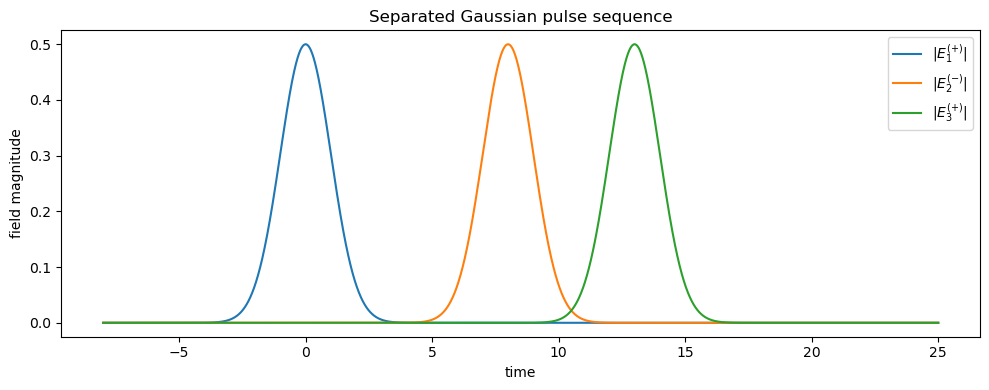

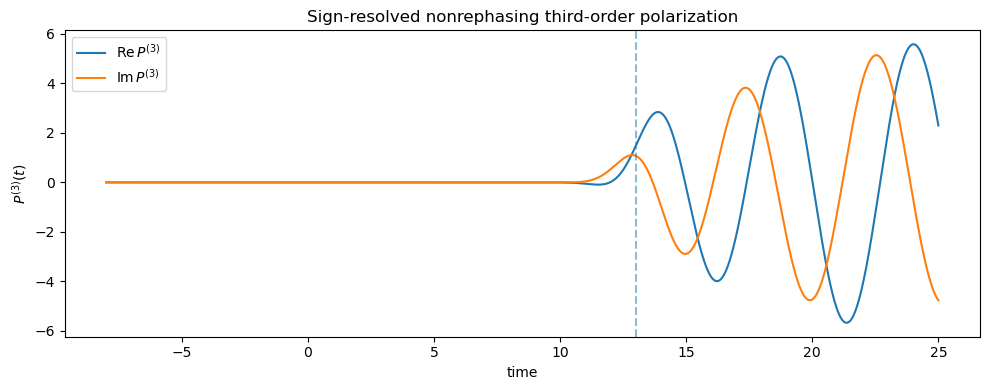

In [54]:
# ============================================================
# Visual sanity check
# ============================================================

E1_t = np.array([
    gaussian_component(t, tau1, +1)
    for t in sol_NR.t
])

E2_t = np.array([
    gaussian_component(t, tau2, -1)
    for t in sol_NR.t
])

E3_t = np.array([
    gaussian_component(t, tau3, +1)
    for t in sol_NR.t
])


plt.figure(figsize=(10, 4))

plt.plot(sol_NR.t, np.abs(E1_t), label=r"$|E_1^{(+)}|$")
plt.plot(sol_NR.t, np.abs(E2_t), label=r"$|E_2^{(-)}|$")
plt.plot(sol_NR.t, np.abs(E3_t), label=r"$|E_3^{(+)}|$")

plt.xlabel("time")
plt.ylabel("field magnitude")
plt.title("Separated Gaussian pulse sequence")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))

plt.plot(sol_NR.t, P3_t.real, label=r"$\mathrm{Re}\,P^{(3)}$")
plt.plot(sol_NR.t, P3_t.imag, label=r"$\mathrm{Im}\,P^{(3)}$")

plt.axvline(tau3, linestyle="--", alpha=0.5)

plt.xlabel("time")
plt.ylabel(r"$P^{(3)}(t)$")
plt.title("Sign-resolved nonrephasing third-order polarization")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# Frequency-resolved explicit ODE benchmark
# ============================================================

def ode_NR_at_t1(t1_delay, rho0_vec=rho_ss_vec):
    """
    Explicit time-domain calculation for one pulse-1/pulse-2
    center delay t1_delay.

    NR field signature: (+, -, +)

    During propagation we directly accumulate the Fourier component
    at w3, including the same eta broadening used in G(w3).

    Returns S(w3, T, t1_delay).
    """

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_wait

    n = d * d

    # Start/end far enough into the Gaussian tails.
    t_start = tau1 - 8.0 * sigma
    t_end   = tau3 + 8.0 * sigma

    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component(t, tau1, +1)
        E2 = gaussian_component(t, tau2, -1)
        E3 = gaussian_component(t, tau3, +1)

        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )

        # Fourier accumulation of the emitted third-order
        # polarization relative to the center of pulse 3.
        detection_weight = np.exp(
            (1j * w3 - eta) * (t - tau3)
        )

        dz = detection_weight * (mu_bra @ rho123)

        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])

    y0 = np.concatenate([
        rho0_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])

    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    rho123_end = sol.y[3*n:4*n, -1]

    # Integral accumulated while the pulses are present
    signal = sol.y[-1, -1]

    # After t_end the Gaussian fields are negligible.
    # Add the remaining field-free polarization analytically.
    v_end = t_end - tau3

    tail = (
        np.exp((1j * w3 - eta) * v_end)
        * (mu_bra @ apply_G(w3, rho123_end))
    )

    return signal + tail

In [57]:
# ============================================================
# Test one pulse-center delay
# ============================================================

t1_test = 10.0

S_w3_test = ode_NR_at_t1(t1_test)

print("t1 delay =", t1_test)
print("S(w3, T, t1) =")
print(S_w3_test)
print("|S| =", abs(S_w3_test))

t1 delay = 10.0
S(w3, T, t1) =
(7.053603979172165-100.45165893987148j)
|S| = 100.69900254157066


In [58]:
# ============================================================
# Direct 2D ODE -> frequency-domain NR signal
# ============================================================

t1_max = 120.0
dt1 = 0.5

t1_grid = np.arange(0.0, t1_max + dt1, dt1)

S_w3_vs_t1 = np.empty(
    len(t1_grid),
    dtype=complex,
)

print("Number of ODE calculations:", len(t1_grid))

for i, t1_delay in enumerate(t1_grid):

    S_w3_vs_t1[i] = ode_NR_at_t1(
        t1_delay,
        rho_ss_vec,
    )

    if i % 25 == 0:
        print(
            f"{i:4d} / {len(t1_grid)-1:4d}   "
            f"t1 = {t1_delay:7.2f}"
        )


# Fourier transform over the first coherence delay.
weight_t1 = np.exp(
    (1j * w1 - eta) * t1_grid
)

A_NR_ODE = np.trapezoid(
    weight_t1 * S_w3_vs_t1,
    t1_grid,
)


print("\nExplicit ODE NR result:")
print(A_NR_ODE)
print("|A_NR_ODE| =", abs(A_NR_ODE))

print("\nFinite-width F result:")
print(A_NR_finite_ss)
print("|A_NR_finite_ss| =", abs(A_NR_finite_ss))

difference = A_NR_ODE - A_NR_finite_ss

print("\nODE - F:")
print(difference)

print("\nRelative difference:")
print(
    abs(difference) / abs(A_NR_finite_ss)
)

Number of ODE calculations: 241
   0 /  240   t1 =    0.00
  25 /  240   t1 =   12.50
  50 /  240   t1 =   25.00
  75 /  240   t1 =   37.50
 100 /  240   t1 =   50.00
 125 /  240   t1 =   62.50
 150 /  240   t1 =   75.00
 175 /  240   t1 =   87.50
 200 /  240   t1 =  100.00
 225 /  240   t1 =  112.50

Explicit ODE NR result:
(-218.13908274246168-2841.6573040144085j)
|A_NR_ODE| = 2850.017700449974

Finite-width F result:
(-192.44775073636936-2949.7257548549105j)
|A_NR_finite_ss| = 2955.9969833573678

ODE - F:
(-25.691332006092324+108.06845084050201j)

Relative difference:
0.03757795006011396


In [59]:
# ============================================================
# Check convergence of the t1 Fourier integral
# using the ODE data already calculated
# ============================================================

cutoffs = [40, 60, 80, 100, 120]

print("t1 cutoff convergence:\n")

for cutoff in cutoffs:

    mask = t1_grid <= cutoff

    A_cut = np.trapezoid(
        weight_t1[mask] * S_w3_vs_t1[mask],
        t1_grid[mask],
    )

    rel_to_F = abs(A_cut - A_NR_finite_ss) / abs(A_NR_finite_ss)

    print(f"t1_max = {cutoff:6.1f}")
    print(f"  A_ODE = {A_cut}")
    print(f"  |A|   = {abs(A_cut):.8f}")
    print(f"  rel. difference from F = {rel_to_F:.6e}")
    print()

t1 cutoff convergence:

t1_max =   40.0
  A_ODE = (-183.9915479397572-2425.607230650406j)
  |A|   = 2432.57545147
  rel. difference from F = 1.773299e-01

t1_max =   60.0
  A_ODE = (-205.0364265876974-2689.9716096097586j)
  |A|   = 2697.77448960
  rel. difference from F = 8.797675e-02

t1_max =   80.0
  A_ODE = (-213.5167558893055-2789.9693021361386j)
  |A|   = 2798.12760822
  rel. difference from F = 5.451283e-02

t1_max =  100.0
  A_ODE = (-216.87537176075637-2827.5739957197725j)
  |A|   = 2835.87898687
  rel. difference from F = 4.214155e-02

t1_max =  120.0
  A_ODE = (-218.13908274246168-2841.6573040144085j)
  |A|   = 2850.01770045
  rel. difference from F = 3.757795e-02



In [60]:
# ============================================================
# How much does the pulse-overlap region contribute?
# ============================================================

t1_mins = [0, 1, 2, 3, 4, 5, 6, 8]

print("Lower t1 cutoff test:\n")

for t1_min in t1_mins:

    mask = t1_grid >= t1_min

    A_cut = np.trapezoid(
        weight_t1[mask] * S_w3_vs_t1[mask],
        t1_grid[mask],
    )

    print(f"t1_min = {t1_min:4.1f}  ({t1_min/sigma:.1f} sigma)")
    print(f"  A = {A_cut}")
    print(f"  |A| = {abs(A_cut):.8f}")
    print()

Lower t1 cutoff test:

t1_min =  0.0  (0.0 sigma)
  A = (-218.13908274246168-2841.6573040144085j)
  |A| = 2850.01770045

t1_min =  1.0  (1.0 sigma)
  A = (-220.5320673388912-2750.7825525479216j)
  |A| = 2759.60849472

t1_min =  2.0  (2.0 sigma)
  A = (-216.80948063280687-2636.440645196538j)
  |A| = 2645.34036119

t1_min =  3.0  (3.0 sigma)
  A = (-211.293639880357-2510.6745983835704j)
  |A| = 2519.54994815

t1_min =  4.0  (4.0 sigma)
  A = (-207.29512294334742-2387.092124206846j)
  |A| = 2396.07597489

t1_min =  5.0  (5.0 sigma)
  A = (-203.7142258906226-2269.941646642293j)
  |A| = 2279.06440563

t1_min =  6.0  (6.0 sigma)
  A = (-201.29034865053407-2160.0419455131514j)
  |A| = 2169.40061096

t1_min =  8.0  (8.0 sigma)
  A = (-194.7674949210681-1962.1786759327217j)
  |A| = 1971.82137461



In [61]:
# ============================================================
# Check t1-grid discretization using existing ODE data
# ============================================================

strides = [1, 2, 4]

print("t1 grid-spacing convergence:\n")

for stride in strides:

    t_sub = t1_grid[::stride]
    S_sub = S_w3_vs_t1[::stride]

    dt_sub = t_sub[1] - t_sub[0]

    weight_sub = np.exp(
        (1j * w1 - eta) * t_sub
    )

    A_sub = np.trapezoid(
        weight_sub * S_sub,
        t_sub,
    )

    rel_to_F = (
        abs(A_sub - A_NR_finite_ss)
        / abs(A_NR_finite_ss)
    )

    print(f"dt1 = {dt_sub:.2f}")
    print(f"  A_ODE = {A_sub}")
    print(f"  |A|   = {abs(A_sub):.8f}")
    print(f"  rel. difference from F = {rel_to_F:.6e}")
    print()

t1 grid-spacing convergence:

dt1 = 0.50
  A_ODE = (-218.13908274246168-2841.6573040144085j)
  |A|   = 2850.01770045
  rel. difference from F = 3.757795e-02

dt1 = 1.00
  A_ODE = (-218.11589057631852-2839.7163018047927j)
  |A|   = 2848.08061973
  rel. difference from F = 3.821530e-02

dt1 = 2.00
  A_ODE = (-218.28489521248278-2831.906241473789j)
  |A|   = 2840.30654261
  rel. difference from F = 4.080492e-02



In [62]:
# ============================================================
# Parameterized Gaussian spectra and F operators
# for pulse-width convergence tests
# ============================================================

def E_spectrum_sigma(omega, s, sigma_test):
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma_test

    return (
        C
        * np.exp(1j * s * phi)
        * np.exp(
            -0.5
            * sigma_test**2
            * (omega - s * omega_L)**2
        )
    )


def F_gaussian_sigma(omega, s, sigma_test, pulse):
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma_test

    if pulse in (1, 3):
        A = (
            L_super
            + 1j * (omega - s * omega_L) * I16
        )

    elif pulse == 2:
        A = (
            L_super
            + 1j * (omega + s * omega_L) * I16
        )

    else:
        raise ValueError("pulse must be 1, 2, or 3")

    return (
        C
        * np.exp(1j * s * phi)
        * expm(
            0.5 * sigma_test**2 * (A @ A)
        )
    )

In [63]:
# ============================================================
# Finite-width F prediction for a narrower pulse
# ============================================================

sigma_test = 0.5

F1_NR_05 = F_gaussian_sigma(
    w1, +1, sigma_test, pulse=1
)

F2_NR_05 = F_gaussian_sigma(
    w1, -1, sigma_test, pulse=2
)

F3_NR_05 = F_gaussian_sigma(
    w3, +1, sigma_test, pulse=3
)

E1_NR_05 = E_spectrum_sigma(
    w1, +1, sigma_test
)


# Stationary-state finite-width response
x = E1_NR_05 * rho_ss_vec

x = V @ x
x = apply_G(w1, x)

x = V @ x

x = F2_NR_05 @ x
x = F3_NR_05 @ x
x = prop_T @ x

x = V @ x
x = apply_G(w3, x)

A_NR_F_05 = mu_bra @ x


print("sigma =", sigma_test)
print("T/sigma =", T_wait / sigma_test)

print("\nFinite-width F result:")
print(A_NR_F_05)
print("|A_NR_F_05| =", abs(A_NR_F_05))

sigma = 0.5
T/sigma = 10.0

Finite-width F result:
(25.20395900941731-388.6740917560313j)
|A_NR_F_05| = 389.4904224138564


In [64]:
# ============================================================
# Parameterized explicit finite-pulse ODE
# ============================================================

def gaussian_component_sigma(t, tau, s, sigma_test):
    u = t - tau

    return (
        E0 / 2
        * np.exp(-u**2 / (2 * sigma_test**2))
        * np.exp(1j * s * phi)
        * np.exp(-1j * s * omega_L * u)
    )


def ode_NR_at_t1_sigma(
    t1_delay,
    sigma_test,
    rho0_vec=rho_ss_vec,
):
    """
    Explicit sign-resolved NR calculation for arbitrary pulse width.

    Field signature:
        (+, -, +)

    Full V is retained at every interaction.
    """

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_wait

    n = d * d

    t_start = tau1 - 8.0 * sigma_test
    t_end   = tau3 + 8.0 * sigma_test

    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component_sigma(
            t, tau1, +1, sigma_test
        )

        E2 = gaussian_component_sigma(
            t, tau2, -1, sigma_test
        )

        E3 = gaussian_component_sigma(
            t, tau3, +1, sigma_test
        )

        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )

        detection_weight = np.exp(
            (1j * w3 - eta) * (t - tau3)
        )

        dz = detection_weight * (
            mu_bra @ rho123
        )

        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])

    y0 = np.concatenate([
        rho0_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])

    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    rho123_end = sol.y[3*n:4*n, -1]

    signal = sol.y[-1, -1]

    v_end = t_end - tau3

    tail = (
        np.exp(
            (1j * w3 - eta) * v_end
        )
        * (
            mu_bra
            @ apply_G(w3, rho123_end)
        )
    )

    return signal + tail

In [65]:
# ============================================================
# ODE benchmark for sigma = 0.5
# ============================================================

t1_grid_05 = np.arange(
    0.0,
    120.0 + 0.5,
    0.5,
)

S_w3_vs_t1_05 = np.empty(
    len(t1_grid_05),
    dtype=complex,
)

print(
    "Number of ODE calculations:",
    len(t1_grid_05),
)

for i, t1_delay in enumerate(t1_grid_05):

    S_w3_vs_t1_05[i] = ode_NR_at_t1_sigma(
        t1_delay,
        sigma_test,
        rho_ss_vec,
    )

    if i % 25 == 0:
        print(
            f"{i:4d} / {len(t1_grid_05)-1:4d}   "
            f"t1 = {t1_delay:7.2f}"
        )


weight_t1_05 = np.exp(
    (1j * w1 - eta) * t1_grid_05
)

A_NR_ODE_05 = np.trapezoid(
    weight_t1_05 * S_w3_vs_t1_05,
    t1_grid_05,
)


rel_err_05 = (
    abs(A_NR_ODE_05 - A_NR_F_05)
    / abs(A_NR_F_05)
)


print("\n====================================")
print("sigma =", sigma_test)
print("T/sigma =", T_wait / sigma_test)

print("\nExplicit ODE:")
print(A_NR_ODE_05)
print("|A_NR_ODE_05| =", abs(A_NR_ODE_05))

print("\nFinite-width F:")
print(A_NR_F_05)
print("|A_NR_F_05| =", abs(A_NR_F_05))

print("\nODE - F:")
print(A_NR_ODE_05 - A_NR_F_05)

print("\nRelative difference:")
print(rel_err_05)

print("\nFor comparison, sigma = 1 error:")
print(
    abs(A_NR_ODE - A_NR_finite_ss)
    / abs(A_NR_finite_ss)
)

Number of ODE calculations: 241
   0 /  240   t1 =    0.00
  25 /  240   t1 =   12.50
  50 /  240   t1 =   25.00
  75 /  240   t1 =   37.50
 100 /  240   t1 =   50.00
 125 /  240   t1 =   62.50
 150 /  240   t1 =   75.00
 175 /  240   t1 =   87.50
 200 /  240   t1 =  100.00
 225 /  240   t1 =  112.50

sigma = 0.5
T/sigma = 10.0

Explicit ODE:
(22.076163446702182-378.6184248388734j)
|A_NR_ODE_05| = 379.2614779014541

Finite-width F:
(25.20395900941731-388.6740917560313j)
|A_NR_F_05| = 389.4904224138564

ODE - F:
(-3.1277955627151286+10.055666917157907j)

Relative difference:
0.02703759721146351

For comparison, sigma = 1 error:
0.03757795006011396


In [66]:
# ============================================================
# Extend the sigma = 0.5 t1 Fourier integral
# to test long-time convergence
# ============================================================

t1_tail_05 = np.arange(
    121.0,
    300.0 + 1.0,
    1.0,
)

S_tail_05 = np.empty(
    len(t1_tail_05),
    dtype=complex,
)

print("Additional ODE calculations:", len(t1_tail_05))

for i, t1_delay in enumerate(t1_tail_05):

    S_tail_05[i] = ode_NR_at_t1_sigma(
        t1_delay,
        sigma_test,
        rho_ss_vec,
    )

    if i % 20 == 0:
        print(
            f"{i:4d} / {len(t1_tail_05)-1:4d}   "
            f"t1 = {t1_delay:7.2f}"
        )


# Combine the original 0 -> 120 grid with the new tail.
t1_extended_05 = np.concatenate([
    t1_grid_05,
    t1_tail_05,
])

S_extended_05 = np.concatenate([
    S_w3_vs_t1_05,
    S_tail_05,
])

weight_extended_05 = np.exp(
    (1j * w1 - eta) * t1_extended_05
)

A_NR_ODE_05_extended = np.trapezoid(
    weight_extended_05 * S_extended_05,
    t1_extended_05,
)

rel_err_05_extended = (
    abs(A_NR_ODE_05_extended - A_NR_F_05)
    / abs(A_NR_F_05)
)

print("\n====================================")
print("Extended t1_max =", t1_extended_05[-1])

print("\nExplicit ODE:")
print(A_NR_ODE_05_extended)
print("|A| =", abs(A_NR_ODE_05_extended))

print("\nFinite-width F:")
print(A_NR_F_05)
print("|A| =", abs(A_NR_F_05))

print("\nRelative difference:")
print(rel_err_05_extended)

print("\nDamping envelope at final t1:")
print(np.exp(-eta * t1_extended_05[-1]))

Additional ODE calculations: 180
   0 /  179   t1 =  121.00
  20 /  179   t1 =  141.00
  40 /  179   t1 =  161.00
  60 /  179   t1 =  181.00
  80 /  179   t1 =  201.00
 100 /  179   t1 =  221.00
 120 /  179   t1 =  241.00
 140 /  179   t1 =  261.00
 160 /  179   t1 =  281.00

Extended t1_max = 300.0

Explicit ODE:
(22.1271722447155-379.73125181921034j)
|A| = 380.37538742633154

Finite-width F:
(25.20395900941731-388.6740917560313j)
|A| = 389.4904224138564

Relative difference:
0.02428127834209276

Damping envelope at final t1:
0.0024787521766663585


In [67]:
# ============================================================
# Explicit ODE with variable waiting time T
# ============================================================

def ode_NR_at_t1_sigma_T(
    t1_delay,
    sigma_test,
    T_test,
    rho0_vec=rho_ss_vec,
):

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_test

    n = d * d

    t_start = tau1 - 8.0 * sigma_test
    t_end   = tau3 + 8.0 * sigma_test

    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component_sigma(
            t, tau1, +1, sigma_test
        )

        E2 = gaussian_component_sigma(
            t, tau2, -1, sigma_test
        )

        E3 = gaussian_component_sigma(
            t, tau3, +1, sigma_test
        )

        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )

        detection_weight = np.exp(
            (1j * w3 - eta) * (t - tau3)
        )

        dz = detection_weight * (
            mu_bra @ rho123
        )

        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])

    y0 = np.concatenate([
        rho0_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])

    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    rho123_end = sol.y[3*n:4*n, -1]

    signal = sol.y[-1, -1]

    v_end = t_end - tau3

    A3 = (eta - 1j * w3) * I16 - L_super

    tail = (
        np.exp((1j * w3 - eta) * v_end)
        * (
            mu_bra
            @ np.linalg.solve(A3, rho123_end)
        )
    )

    return signal + tail

In [68]:
# ============================================================
# F prediction for sigma = 0.5, T = 10
# ============================================================

T_test = 10.0
prop_T_10 = expm(L_super * T_test)

x = E1_NR_05 * rho_ss_vec

x = V @ x
x = apply_G(w1, x)

x = V @ x

x = F2_NR_05 @ x
x = F3_NR_05 @ x
x = prop_T_10 @ x

x = V @ x
x = apply_G(w3, x)

A_NR_F_05_T10 = mu_bra @ x

print("sigma =", sigma_test)
print("T =", T_test)
print("T/sigma =", T_test / sigma_test)

print("\nFinite-width F:")
print(A_NR_F_05_T10)
print("|A| =", abs(A_NR_F_05_T10))

sigma = 0.5
T = 10.0
T/sigma = 20.0

Finite-width F:
(-14.040140962095442-257.875054130374j)
|A| = 258.25698267612984


In [69]:
# ============================================================
# ODE benchmark: sigma = 0.5, T = 10
# ============================================================

t1_grid_T10 = np.arange(
    0.0,
    300.0 + 1.0,
    1.0,
)

S_T10 = np.empty(
    len(t1_grid_T10),
    dtype=complex,
)

print("Number of ODE calculations:", len(t1_grid_T10))

for i, t1_delay in enumerate(t1_grid_T10):

    S_T10[i] = ode_NR_at_t1_sigma_T(
        t1_delay,
        sigma_test,
        T_test,
        rho_ss_vec,
    )

    if i % 30 == 0:
        print(
            f"{i:4d} / {len(t1_grid_T10)-1:4d}   "
            f"t1 = {t1_delay:7.2f}"
        )


weight_T10 = np.exp(
    (1j * w1 - eta) * t1_grid_T10
)

A_NR_ODE_05_T10 = np.trapezoid(
    weight_T10 * S_T10,
    t1_grid_T10,
)

rel_err_T10 = (
    abs(A_NR_ODE_05_T10 - A_NR_F_05_T10)
    / abs(A_NR_F_05_T10)
)

print("\n====================================")

print("ODE:")
print(A_NR_ODE_05_T10)
print("|A| =", abs(A_NR_ODE_05_T10))

print("\nF result:")
print(A_NR_F_05_T10)
print("|A| =", abs(A_NR_F_05_T10))

print("\nRelative difference:")
print(rel_err_T10)

print("\nPrevious converged-ish result:")
print("sigma = 0.5, T = 5  ->", rel_err_05_extended)

Number of ODE calculations: 301
   0 /  300   t1 =    0.00
  30 /  300   t1 =   30.00
  60 /  300   t1 =   60.00
  90 /  300   t1 =   90.00
 120 /  300   t1 =  120.00
 150 /  300   t1 =  150.00
 180 /  300   t1 =  180.00
 210 /  300   t1 =  210.00
 240 /  300   t1 =  240.00
 270 /  300   t1 =  270.00
 300 /  300   t1 =  300.00

ODE:
(-16.67405779626951-251.24006341778977j)
|A| = 251.79275936684192

F result:
(-14.040140962095442-257.875054130374j)
|A| = 258.25698267612984

Relative difference:
0.027641733616670276

Previous converged-ish result:
sigma = 0.5, T = 5  -> 0.02428127834209276


In [70]:
# ============================================================
# ODE benchmark allowing negative pulse-center delays
# ============================================================

def ode_NR_at_t1_fullscan(
    t1_delay,
    sigma_test,
    T_test,
    rho0_vec=rho_ss_vec,
):

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_test

    n = d * d

    # Important for negative center delays:
    # begin before the earliest pulse center.
    t_start = min(tau1, tau2, tau3) - 8.0 * sigma_test
    t_end   = max(tau1, tau2, tau3) + 8.0 * sigma_test

    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component_sigma(
            t, tau1, +1, sigma_test
        )

        E2 = gaussian_component_sigma(
            t, tau2, -1, sigma_test
        )

        E3 = gaussian_component_sigma(
            t, tau3, +1, sigma_test
        )

        drho0 = L_super @ rho0

        # The perturbative hierarchy itself enforces
        # interaction order 1 -> 2 -> 3.
        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )

        detection_weight = np.exp(
            (1j * w3 - eta) * (t - tau3)
        )

        dz = detection_weight * (
            mu_bra @ rho123
        )

        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])

    y0 = np.concatenate([
        rho0_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])

    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    rho123_end = sol.y[3*n:4*n, -1]

    signal = sol.y[-1, -1]

    v_end = t_end - tau3

    tail = (
        np.exp((1j * w3 - eta) * v_end)
        * (
            mu_bra
            @ apply_G(w3, rho123_end)
        )
    )

    return signal + tail

In [71]:
# ============================================================
# Negative pulse-center-delay contribution
# sigma = 0.5, T = 10
# ============================================================

t1_negative = np.arange(
    -5.0,
    0.0,
    0.25,
)

S_negative = np.empty(
    len(t1_negative),
    dtype=complex,
)

print("Negative-delay ODE calculations:", len(t1_negative))

for i, t1_delay in enumerate(t1_negative):

    S_negative[i] = ode_NR_at_t1_fullscan(
        t1_delay,
        sigma_test,
        T_test,
        rho_ss_vec,
    )

    print(
        f"{i:3d} / {len(t1_negative)-1:3d}   "
        f"t1 = {t1_delay:6.2f}"
    )


# Combine negative-delay data with the existing
# T = 10 positive-delay data.
t1_full = np.concatenate([
    t1_negative,
    t1_grid_T10,
])

S_full = np.concatenate([
    S_negative,
    S_T10,
])

weight_full = np.exp(
    (1j * w1 - eta) * t1_full
)

A_NR_ODE_fullscan = np.trapezoid(
    weight_full * S_full,
    t1_full,
)

rel_err_fullscan = (
    abs(A_NR_ODE_fullscan - A_NR_F_05_T10)
    / abs(A_NR_F_05_T10)
)

print("\n====================================")

print("ODE, t1 >= 0:")
print(A_NR_ODE_05_T10)

print("\nODE including negative center delays:")
print(A_NR_ODE_fullscan)
print("|A| =", abs(A_NR_ODE_fullscan))

print("\nFinite-width F:")
print(A_NR_F_05_T10)
print("|A| =", abs(A_NR_F_05_T10))

print("\nRelative difference, t1 >= 0:")
print(rel_err_T10)

print("\nRelative difference, full center-delay scan:")
print(rel_err_fullscan)

Negative-delay ODE calculations: 20
  0 /  19   t1 =  -5.00
  1 /  19   t1 =  -4.75
  2 /  19   t1 =  -4.50
  3 /  19   t1 =  -4.25
  4 /  19   t1 =  -4.00
  5 /  19   t1 =  -3.75
  6 /  19   t1 =  -3.50
  7 /  19   t1 =  -3.25
  8 /  19   t1 =  -3.00
  9 /  19   t1 =  -2.75
 10 /  19   t1 =  -2.50
 11 /  19   t1 =  -2.25
 12 /  19   t1 =  -2.00
 13 /  19   t1 =  -1.75
 14 /  19   t1 =  -1.50
 15 /  19   t1 =  -1.25
 16 /  19   t1 =  -1.00
 17 /  19   t1 =  -0.75
 18 /  19   t1 =  -0.50
 19 /  19   t1 =  -0.25

ODE, t1 >= 0:
(-16.67405779626951-251.24006341778977j)

ODE including negative center delays:
(-15.780414513297005-257.3963602107662j)
|A| = 257.8796380716438

Finite-width F:
(-14.040140962095442-257.875054130374j)
|A| = 258.25698267612984

Relative difference, t1 >= 0:
0.027641733616670276

Relative difference, full center-delay scan:
0.006988813716146002


In [72]:
# ============================================================
# Refine the pulse-center-delay integral near t1 = 0
# sigma = 0.5, T = 10
# ============================================================

t1_fine = np.arange(
    -8.0,
    8.0 + 0.25,
    0.25,
)

S_fine = np.empty(
    len(t1_fine),
    dtype=complex,
)

print("Fine-region ODE calculations:", len(t1_fine))

for i, t1_delay in enumerate(t1_fine):

    S_fine[i] = ode_NR_at_t1_fullscan(
        t1_delay,
        sigma_test,
        T_test,
        rho_ss_vec,
    )

    if i % 10 == 0:
        print(
            f"{i:3d} / {len(t1_fine)-1:3d}   "
            f"t1 = {t1_delay:7.2f}"
        )


# Reuse the already-computed coarse positive-delay tail.
tail_mask = t1_grid_T10 > 8.0

t1_tail_existing = t1_grid_T10[tail_mask]
S_tail_existing = S_T10[tail_mask]


# Combine the fine central region with the long-time tail.
t1_refined = np.concatenate([
    t1_fine,
    t1_tail_existing,
])

S_refined = np.concatenate([
    S_fine,
    S_tail_existing,
])

weight_refined = np.exp(
    (1j * w1 - eta) * t1_refined
)

A_NR_ODE_refined = np.trapezoid(
    weight_refined * S_refined,
    t1_refined,
)

rel_err_refined = (
    abs(A_NR_ODE_refined - A_NR_F_05_T10)
    / abs(A_NR_F_05_T10)
)

print("\n====================================")

print("Refined ODE:")
print(A_NR_ODE_refined)
print("|A| =", abs(A_NR_ODE_refined))

print("\nFinite-width F:")
print(A_NR_F_05_T10)
print("|A| =", abs(A_NR_F_05_T10))

print("\nODE - F:")
print(A_NR_ODE_refined - A_NR_F_05_T10)

print("\nRelative difference:")
print(rel_err_refined)

print("\nPrevious full-scan error:")
print(rel_err_fullscan)

Fine-region ODE calculations: 65
  0 /  64   t1 =   -8.00
 10 /  64   t1 =   -5.50
 20 /  64   t1 =   -3.00
 30 /  64   t1 =   -0.50
 40 /  64   t1 =    2.00
 50 /  64   t1 =    4.50
 60 /  64   t1 =    7.00

Refined ODE:
(-15.711981194132935-258.2343429572046j)
|A| = 258.71189040240097

Finite-width F:
(-14.040140962095442-257.875054130374j)
|A| = 258.25698267612984

ODE - F:
(-1.6718402320374928-0.3592888268306069j)

Relative difference:
0.006621355048860525

Previous full-scan error:
0.006988813716146002


In [73]:
# ============================================================
# Finite-eta Liouvillian pulse operators
# ============================================================

def F_gaussian_eta(omega, s, sigma_test, pulse):
    """
    Gaussian F operator with the same finite eta used
    in the numerical Fourier transforms.

    For eta -> 0 this reduces to the previous F operator.
    """
    C = E0 / 2 * np.sqrt(2 * np.pi) * sigma_test

    if pulse in (1, 3):

        A = (
            L_super
            - eta * I16
            + 1j * (omega - s * omega_L) * I16
        )

    elif pulse == 2:

        A = (
            L_super
            - eta * I16
            + 1j * (omega + s * omega_L) * I16
        )

    else:
        raise ValueError("pulse must be 1, 2, or 3")

    return (
        C
        * np.exp(1j * s * phi)
        * expm(
            0.5 * sigma_test**2 * (A @ A)
        )
    )


# NR signature (+, -, +)
F1_NR_eta = F_gaussian_eta(
    w1, +1, sigma_test, pulse=1
)

F2_NR_eta = F_gaussian_eta(
    w1, -1, sigma_test, pulse=2
)

F3_NR_eta = F_gaussian_eta(
    w3, +1, sigma_test, pulse=3
)


# General F1 F2 F3 result.
# Do NOT replace F1 by the ordinary E1 here,
# because at finite eta the exact scalar reduction is modified.
x = F1_NR_eta @ rho_ss_vec

x = V @ x
x = apply_G(w1, x)

x = V @ x

x = F2_NR_eta @ x
x = F3_NR_eta @ x

x = prop_T_10 @ x

x = V @ x
x = apply_G(w3, x)

A_NR_F_eta = mu_bra @ x


rel_err_eta = (
    abs(A_NR_ODE_refined - A_NR_F_eta)
    / abs(A_NR_F_eta)
)


print("Refined explicit ODE:")
print(A_NR_ODE_refined)
print("|A| =", abs(A_NR_ODE_refined))

print("\nFinite-width F, eta included in pulse offsets:")
print(A_NR_F_eta)
print("|A| =", abs(A_NR_F_eta))

print("\nODE - F_eta:")
print(A_NR_ODE_refined - A_NR_F_eta)

print("\nRelative difference:")
print(rel_err_eta)

print("\nPrevious F result without eta in F_j:")
print(A_NR_F_05_T10)

print("Previous relative difference:")
print(rel_err_refined)

Refined explicit ODE:
(-15.711981194132935-258.2343429572046j)
|A| = 258.71189040240097

Finite-width F, eta included in pulse offsets:
(-15.36333628185233-257.82689549452704j)
|A| = 258.28422356399363

ODE - F_eta:
(-0.348644912280605-0.4074474626775668j)

Relative difference:
0.0020762106986168187

Previous F result without eta in F_j:
(-14.040140962095442-257.875054130374j)
Previous relative difference:
0.006621355048860525


In [74]:
# ============================================================
# Final long-t1 convergence test
# sigma = 0.5, T = 10
# ============================================================

t1_extra = np.arange(
    301.0,
    500.0 + 1.0,
    1.0,
)

S_extra = np.empty(
    len(t1_extra),
    dtype=complex,
)

print("Additional ODE calculations:", len(t1_extra))

for i, t1_delay in enumerate(t1_extra):

    S_extra[i] = ode_NR_at_t1_sigma_T(
        t1_delay,
        sigma_test,
        T_test,
        rho_ss_vec,
    )

    if i % 25 == 0:
        print(
            f"{i:4d} / {len(t1_extra)-1:4d}   "
            f"t1 = {t1_delay:7.2f}"
        )


# Fine region already calculated: -8 <= t1 <= 8
# Existing coarse tail: 9 <= t1 <= 300
existing_tail_mask = t1_grid_T10 > 8.0

t1_existing_tail = t1_grid_T10[existing_tail_mask]
S_existing_tail = S_T10[existing_tail_mask]


# Assemble the complete refined grid.
t1_final = np.concatenate([
    t1_fine,
    t1_existing_tail,
    t1_extra,
])

S_final = np.concatenate([
    S_fine,
    S_existing_tail,
    S_extra,
])

weight_final = np.exp(
    (1j * w1 - eta) * t1_final
)

A_NR_ODE_final = np.trapezoid(
    weight_final * S_final,
    t1_final,
)

rel_err_final = (
    abs(A_NR_ODE_final - A_NR_F_eta)
    / abs(A_NR_F_eta)
)


print("\n====================================")

print("Final ODE:")
print(A_NR_ODE_final)
print("|A| =", abs(A_NR_ODE_final))

print("\nFinite-width F_eta:")
print(A_NR_F_eta)
print("|A| =", abs(A_NR_F_eta))

print("\nODE - F_eta:")
print(A_NR_ODE_final - A_NR_F_eta)

print("\nRelative difference:")
print(rel_err_final)

print("\nFourier damping at t1_max = 500:")
print(np.exp(-eta * 500.0))

print("\nPrevious error at t1_max = 300:")
print(rel_err_eta)

Additional ODE calculations: 200
   0 /  199   t1 =  301.00
  25 /  199   t1 =  326.00
  50 /  199   t1 =  351.00
  75 /  199   t1 =  376.00
 100 /  199   t1 =  401.00
 125 /  199   t1 =  426.00
 150 /  199   t1 =  451.00
 175 /  199   t1 =  476.00

Final ODE:
(-15.71198532056147-258.23446037303944j)
|A| = 258.71200785210647

Finite-width F_eta:
(-15.36333628185233-257.82689549452704j)
|A| = 258.28422356399363

ODE - F_eta:
(-0.348649038709139-0.4075648785124031j)

Relative difference:
0.00207656651194201

Fourier damping at t1_max = 500:
4.5399929762484854e-05

Previous error at t1_max = 300:
0.0020762106986168187


In [75]:
# ============================================================
# Independent quadrature check of finite-eta F operators
# ============================================================

def F1_eta_quadrature(omega, s, sigma_test):
    F = np.zeros_like(L_super, dtype=complex)

    prefactor = (
        np.sqrt(2) * sigma_test
        * E0 / 2
        * np.exp(1j * s * phi)
    )

    for x, weight in zip(x_gh, w_gh):
        u = np.sqrt(2) * sigma_test * x

        phase = np.exp(
            (1j * (omega - s * omega_L) - eta) * u
        )

        F += (
            weight
            * phase
            * expm(L_super * u)
        )

    return prefactor * F


def F2_eta_quadrature(omega, s, sigma_test):
    F = np.zeros_like(L_super, dtype=complex)

    prefactor = (
        np.sqrt(2) * sigma_test
        * E0 / 2
        * np.exp(1j * s * phi)
    )

    for x, weight in zip(x_gh, w_gh):
        u = np.sqrt(2) * sigma_test * x

        phase = np.exp(
            (-1j * (omega + s * omega_L) + eta) * u
        )

        F += (
            weight
            * phase
            * expm(-L_super * u)
        )

    return prefactor * F


def F3_eta_quadrature(omega, s, sigma_test):
    return F1_eta_quadrature(
        omega,
        s,
        sigma_test,
    )


F1_eta_num = F1_eta_quadrature(
    w1, +1, sigma_test
)

F2_eta_num = F2_eta_quadrature(
    w1, -1, sigma_test
)

F3_eta_num = F3_eta_quadrature(
    w3, +1, sigma_test
)


print("Finite-eta analytic vs quadrature errors:")

print(
    "F1:",
    norm(F1_eta_num - F1_NR_eta)
    / norm(F1_NR_eta)
)

print(
    "F2:",
    norm(F2_eta_num - F2_NR_eta)
    / norm(F2_NR_eta)
)

print(
    "F3:",
    norm(F3_eta_num - F3_NR_eta)
    / norm(F3_NR_eta)
)

Finite-eta analytic vs quadrature errors:
F1: 2.3913133447876677e-16
F2: 3.0392148417417637e-16
F3: 2.3913133447876677e-16


In [76]:
# ============================================================
# Nonstationary prepared ground state
# ============================================================

tau_prep = 12.0

# State at the center of pulse 1 after field-free evolution
rho_g_center_vec = (
    expm(L_super * tau_prep)
    @ rho_g_vec
)

rho_g_center = rho_g_center_vec.reshape(
    (d, d),
    order="F",
)

print("Preparation-to-pulse-1-center delay =", tau_prep)

print("\nState at preparation:")
print(rho_g)

print("\nState at center of pulse 1:")
print(rho_g_center)

print("\nTrace =", np.trace(rho_g_center))

print(
    "\n||rho(center) - rho_g|| =",
    norm(rho_g_center_vec - rho_g_vec),
)

print(
    "||rho(center) - rho_ss|| =",
    norm(rho_g_center_vec - rho_ss_vec),
)

print(
    "||L rho(center)|| =",
    norm(L_super @ rho_g_center_vec),
)

Preparation-to-pulse-1-center delay = 12.0

State at preparation:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

State at center of pulse 1:
[[ 0.95656 -0.j  0.      +0.j  0.      +0.j  0.      +0.j]
 [ 0.      +0.j  0.021479+0.j -0.      -0.j  0.      +0.j]
 [ 0.      +0.j -0.      -0.j  0.021479-0.j  0.      +0.j]
 [ 0.      +0.j  0.      +0.j  0.      +0.j  0.000482-0.j]]

Trace = (1.0000000000000002+8.608660497553128e-20j)

||rho(center) - rho_g|| = 0.05300932119838158
||rho(center) - rho_ss|| = 0.05499051377420558
||L rho(center)|| = 0.003073075625133208


In [77]:
# ============================================================
# Full F1 F2 F3 prediction for the nonstationary preparation
# ============================================================

x = (
    F1_NR_eta
    @ rho_g_center_vec
)

x = V @ x
x = apply_G(w1, x)

x = V @ x

x = F2_NR_eta @ x
x = F3_NR_eta @ x

x = prop_T_10 @ x

x = V @ x
x = apply_G(w3, x)

A_NR_F_eta_ground = mu_bra @ x


print("Full F1F2F3 prepared-state result:")
print(A_NR_F_eta_ground)
print("|A| =", abs(A_NR_F_eta_ground))

Full F1F2F3 prepared-state result:
(-17.382770224898756-276.23434850420574j)
|A| = 276.78073631348445


In [78]:
# ============================================================
# How important is the nontrivial F1 correction?
# ============================================================

def E_spectrum_eta(
    omega,
    s,
    sigma_test,
):
    """
    Scalar Gaussian pulse integral with the same finite eta
    convention used in the numerical Fourier transform.
    """
    C = (
        E0 / 2
        * np.sqrt(2 * np.pi)
        * sigma_test
    )

    z = (
        -eta
        + 1j * (omega - s * omega_L)
    )

    return (
        C
        * np.exp(1j * s * phi)
        * np.exp(
            0.5 * sigma_test**2 * z**2
        )
    )


E1_eta_05 = E_spectrum_eta(
    w1,
    +1,
    sigma_test,
)


# Incorrect frozen/scalar treatment of pulse 1
x = E1_eta_05 * rho_g_center_vec

x = V @ x
x = apply_G(w1, x)

x = V @ x

x = F2_NR_eta @ x
x = F3_NR_eta @ x

x = prop_T_10 @ x

x = V @ x
x = apply_G(w3, x)

A_NR_F_scalar1_ground = mu_bra @ x


print("Full nonstationary F1 result:")
print(A_NR_F_eta_ground)

print("\nScalar-pulse-1 approximation:")
print(A_NR_F_scalar1_ground)

print("\nRelative error from replacing F1 by E1:")
print(
    abs(
        A_NR_F_scalar1_ground
        - A_NR_F_eta_ground
    )
    / abs(A_NR_F_eta_ground)
)

Full nonstationary F1 result:
(-17.382770224898756-276.23434850420574j)

Scalar-pulse-1 approximation:
(-17.345109471982138-276.2259820880221j)

Relative error from replacing F1 by E1:
0.00013938423160127886


In [79]:
# ============================================================
# Explicit ODE for a nonstationary prepared state
# ============================================================

def ode_NR_prepared(
    t1_delay,
    sigma_test,
    T_test,
    tau_prep,
):
    """
    Explicit sign-resolved NR calculation for a state prepared
    as rho_g at t = -tau_prep.

    Pulse 1 is centered at t = 0.
    Pulse 2 is centered at t = t1_delay.
    Pulse 3 is centered at t = t1_delay + T_test.

    Field signature: (+, -, +)
    Full V is retained.
    """

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_test

    t_prep = -tau_prep

    n = d * d

    # Propagation begins at the actual preparation time.
    t_start = t_prep

    # Propagate sufficiently beyond all pulses.
    t_end = max(tau1, tau2, tau3) + 8.0 * sigma_test

    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component_sigma(
            t, tau1, +1, sigma_test
        )

        E2 = gaussian_component_sigma(
            t, tau2, -1, sigma_test
        )

        E3 = gaussian_component_sigma(
            t, tau3, +1, sigma_test
        )

        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )

        detection_weight = np.exp(
            (1j * w3 - eta) * (t - tau3)
        )

        dz = detection_weight * (
            mu_bra @ rho123
        )

        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])

    # At the actual preparation time the system is exactly |gg><gg|.
    y0 = np.concatenate([
        rho_g_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])

    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    rho123_end = sol.y[3*n:4*n, -1]

    signal = sol.y[-1, -1]

    v_end = t_end - tau3

    tail = (
        np.exp((1j * w3 - eta) * v_end)
        * (
            mu_bra
            @ apply_G(w3, rho123_end)
        )
    )

    return signal + tail

In [80]:
# ============================================================
# One-delay prepared-state ODE sanity check
# ============================================================

S_prepared_test = ode_NR_prepared(
    t1_delay=10.0,
    sigma_test=sigma_test,
    T_test=T_test,
    tau_prep=tau_prep,
)

print("Prepared-state ODE at t1 = 10:")
print(S_prepared_test)
print("|S| =", abs(S_prepared_test))

Prepared-state ODE at t1 = 10:
(-0.4012901133234183-11.86221926072918j)
|S| = 11.869004993876509


In [81]:
# ============================================================
# Full prepared-state ODE -> frequency-domain benchmark
# ============================================================

t1_prepared_fine = np.arange(
    -8.0,
    8.0 + 0.25,
    0.25,
)

t1_prepared_tail = np.arange(
    9.0,
    300.0 + 1.0,
    1.0,
)

t1_prepared_grid = np.concatenate([
    t1_prepared_fine,
    t1_prepared_tail,
])

S_prepared = np.empty(
    len(t1_prepared_grid),
    dtype=complex,
)

print("Number of prepared-state ODE calculations:",
      len(t1_prepared_grid))

for i, t1_delay in enumerate(t1_prepared_grid):

    S_prepared[i] = ode_NR_prepared(
        t1_delay=t1_delay,
        sigma_test=sigma_test,
        T_test=T_test,
        tau_prep=tau_prep,
    )

    if i % 30 == 0:
        print(
            f"{i:4d} / {len(t1_prepared_grid)-1:4d}   "
            f"t1 = {t1_delay:8.2f}"
        )


weight_prepared = np.exp(
    (1j * w1 - eta) * t1_prepared_grid
)

A_NR_ODE_prepared = np.trapezoid(
    weight_prepared * S_prepared,
    t1_prepared_grid,
)

rel_err_prepared = (
    abs(A_NR_ODE_prepared - A_NR_F_eta_ground)
    / abs(A_NR_F_eta_ground)
)


print("\n====================================")

print("Prepared-state explicit ODE:")
print(A_NR_ODE_prepared)
print("|A| =", abs(A_NR_ODE_prepared))

print("\nPrepared-state F1F2F3:")
print(A_NR_F_eta_ground)
print("|A| =", abs(A_NR_F_eta_ground))

print("\nODE - F:")
print(A_NR_ODE_prepared - A_NR_F_eta_ground)

print("\nRelative difference:")
print(rel_err_prepared)

Number of prepared-state ODE calculations: 357
   0 /  356   t1 =    -8.00
  30 /  356   t1 =    -0.50
  60 /  356   t1 =     7.00
  90 /  356   t1 =    34.00
 120 /  356   t1 =    64.00
 150 /  356   t1 =    94.00
 180 /  356   t1 =   124.00
 210 /  356   t1 =   154.00
 240 /  356   t1 =   184.00
 270 /  356   t1 =   214.00
 300 /  356   t1 =   244.00
 330 /  356   t1 =   274.00

Prepared-state explicit ODE:
(-17.752058466950697-276.6720334904201j)
|A| = 277.24095962815124

Prepared-state F1F2F3:
(-17.382770224898756-276.23434850420574j)
|A| = 276.78073631348445

ODE - F:
(-0.36928824205194033-0.43768498621437857j)

Relative difference:
0.0020690101868289954


In [82]:
# ============================================================
# Prepared-state comparison:
# explicit ODE vs full F1 vs frozen pulse-1 approximation
# ============================================================

err_full_F1 = (
    abs(A_NR_ODE_prepared - A_NR_F_eta_ground)
    / abs(A_NR_ODE_prepared)
)

err_frozen_F1 = (
    abs(A_NR_ODE_prepared - A_NR_F_scalar1_ground)
    / abs(A_NR_ODE_prepared)
)

F1_correction = (
    abs(A_NR_F_eta_ground - A_NR_F_scalar1_ground)
    / abs(A_NR_F_eta_ground)
)


print("Explicit prepared-state ODE:")
print(A_NR_ODE_prepared)
print("|A| =", abs(A_NR_ODE_prepared))

print("\nFull F1F2F3:")
print(A_NR_F_eta_ground)
print("|A| =", abs(A_NR_F_eta_ground))

print("\nFrozen pulse-1 approximation (E1F2F3):")
print(A_NR_F_scalar1_ground)
print("|A| =", abs(A_NR_F_scalar1_ground))

print("\n------------------------------------")
print("ODE vs full F1 relative error:")
print(err_full_F1)

print("\nODE vs frozen E1 relative error:")
print(err_frozen_F1)

print("\nIntrinsic F1 correction:")
print(F1_correction)

Explicit prepared-state ODE:
(-17.752058466950697-276.6720334904201j)
|A| = 277.24095962815124

Full F1F2F3:
(-17.382770224898756-276.23434850420574j)
|A| = 276.78073631348445

Frozen pulse-1 approximation (E1F2F3):
(-17.345109471982138-276.2259820880221j)
|A| = 276.7700236714362

------------------------------------
ODE vs full F1 relative error:
0.0020655756051295997

ODE vs frozen E1 relative error:
0.0021778736300665695

Intrinsic F1 correction:
0.00013938423160127886


In [83]:
# ============================================================
# Separate the two prepared-state approximations:
#
# 1. Full:
#       F1 exp(L tau_prep) rho_g
#
# 2. Frozen during pulse 1:
#       E1 exp(L tau_prep) rho_g
#
# 3. Frozen preparation delay:
#       F1 rho_g
#
# 4. Fully frozen:
#       E1 rho_g
# ============================================================

def finish_NR_from_first_pulse_state(x):
    """
    x is the Liouville-space state after applying either
    F1 or E1, but before the first molecular interaction V.
    """

    x = V @ x
    x = apply_G(w1, x)

    x = V @ x

    x = F2_NR_eta @ x
    x = F3_NR_eta @ x

    x = prop_T_10 @ x

    x = V @ x
    x = apply_G(w3, x)

    return mu_bra @ x


# ------------------------------------------------------------
# 1. Full treatment
# F1 exp(L tau_prep) rho_g
# ------------------------------------------------------------

x_full = (
    F1_NR_eta
    @ rho_g_center_vec
)

A_full = finish_NR_from_first_pulse_state(
    x_full
)


# ------------------------------------------------------------
# 2. Freeze evolution across pulse 1 only
# E1 exp(L tau_prep) rho_g
# ------------------------------------------------------------

x_frozen_width = (
    E1_eta_05
    * rho_g_center_vec
)

A_frozen_width = finish_NR_from_first_pulse_state(
    x_frozen_width
)


# ------------------------------------------------------------
# 3. Ignore preparation-to-pulse evolution only
# F1 rho_g
# ------------------------------------------------------------

x_frozen_delay = (
    F1_NR_eta
    @ rho_g_vec
)

A_frozen_delay = finish_NR_from_first_pulse_state(
    x_frozen_delay
)


# ------------------------------------------------------------
# 4. Ignore both preparation evolution and
#    evolution across pulse 1
# E1 rho_g
# ------------------------------------------------------------

x_fully_frozen = (
    E1_eta_05
    * rho_g_vec
)

A_fully_frozen = finish_NR_from_first_pulse_state(
    x_fully_frozen
)


# ------------------------------------------------------------
# Compare everything with the explicit prepared-state ODE
# ------------------------------------------------------------

cases = {
    "Explicit ODE": A_NR_ODE_prepared,
    "Full F1 exp(L tau_prep)": A_full,
    "Frozen pulse width: E1 exp(L tau_prep)": A_frozen_width,
    "Frozen prep delay: F1 rho_g": A_frozen_delay,
    "Fully frozen: E1 rho_g": A_fully_frozen,
}


for name, value in cases.items():

    print(name)
    print("  A =", value)
    print("  |A| =", abs(value))

    if name != "Explicit ODE":
        err = (
            abs(value - A_NR_ODE_prepared)
            / abs(A_NR_ODE_prepared)
        )
        print("  relative error vs ODE =", err)

    print()

Explicit ODE
  A = (-17.752058466950697-276.6720334904201j)
  |A| = 277.24095962815124

Full F1 exp(L tau_prep)
  A = (-17.382770224898756-276.23434850420574j)
  |A| = 276.78073631348445
  relative error vs ODE = 0.0020655756051295997

Frozen pulse width: E1 exp(L tau_prep)
  A = (-17.345109471982138-276.2259820880221j)
  |A| = 276.7700236714362
  relative error vs ODE = 0.0021778736300665695

Frozen prep delay: F1 rho_g
  A = (-19.378066575055183-293.89294914713037j)
  |A| = 294.53111044944814
  relative error vs ODE = 0.062391609179845445

Fully frozen: E1 rho_g
  A = (-19.303226319712422-293.8762456854526j)
  |A| = 294.50952841041754
  relative error vs ODE = 0.062306806869419376



In [84]:
# ============================================================
# Preparation-delay scan
#
# Compare:
#   full:          F1 exp(L tau_prep) rho_g
#   frozen delay:  F1 rho_g
#
# sigma1 = sigma2 = sigma3 = 0.5
# ============================================================

tau_prep_values = np.linspace(
    4.0,
    40.0,
    73,
)

A_full_tau = np.empty(
    len(tau_prep_values),
    dtype=complex,
)

A_frozen_delay_tau = np.empty(
    len(tau_prep_values),
    dtype=complex,
)

err_frozen_delay_tau = np.empty(
    len(tau_prep_values)
)


# Frozen-delay result does not depend on tau_prep
A_frozen_reference = finish_NR_from_first_pulse_state(
    F1_NR_eta @ rho_g_vec
)


for i, tau in enumerate(tau_prep_values):

    rho_center = (
        expm(L_super * tau)
        @ rho_g_vec
    )

    A_full_tau[i] = finish_NR_from_first_pulse_state(
        F1_NR_eta @ rho_center
    )

    A_frozen_delay_tau[i] = A_frozen_reference

    err_frozen_delay_tau[i] = (
        abs(
            A_frozen_reference
            - A_full_tau[i]
        )
        / abs(A_full_tau[i])
    )


print("tau_prep = 12:")
i12 = np.argmin(
    abs(tau_prep_values - 12.0)
)

print(
    "relative frozen-delay error =",
    err_frozen_delay_tau[i12]
)

print("\ntau_prep = 40:")
print(
    "relative frozen-delay error =",
    err_frozen_delay_tau[-1]
)

tau_prep = 12:
relative frozen-delay error = 0.06420595053900434

tau_prep = 40:
relative frozen-delay error = 0.1234210538457963


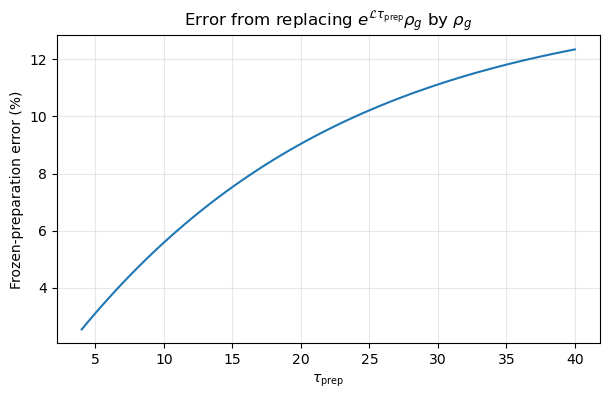

In [85]:
plt.figure(figsize=(7, 4))

plt.plot(
    tau_prep_values,
    100 * err_frozen_delay_tau,
)

plt.xlabel(r"$\tau_{\rm prep}$")
plt.ylabel("Frozen-preparation error (%)")

plt.title(
    r"Error from replacing "
    r"$e^{\mathcal{L}\tau_{\rm prep}}\rho_g$ "
    r"by $\rho_g$"
)

plt.grid(alpha=0.3)
plt.show()

In [86]:
# ============================================================
# Pulse-1-width scan
#
# Compare:
#   full:    F1 exp(L tau_prep) rho_g
#   frozen:  E1 exp(L tau_prep) rho_g
#
# Keep sigma2 = sigma3 = 0.5 fixed.
# ============================================================

sigma1_values = np.linspace(
    0.25,
    1.50,
    51,
)

tau_prep_scan = 12.0

rho_center_scan = (
    expm(L_super * tau_prep_scan)
    @ rho_g_vec
)

A_full_sigma1 = np.empty(
    len(sigma1_values),
    dtype=complex,
)

A_frozen_sigma1 = np.empty(
    len(sigma1_values),
    dtype=complex,
)

err_frozen_sigma1 = np.empty(
    len(sigma1_values)
)


for i, sigma1_test in enumerate(sigma1_values):

    # Full finite-width pulse-1 operator
    F1_test = F_gaussian_eta(
        w1,
        +1,
        sigma1_test,
        pulse=1,
    )

    # Scalar/frozen pulse-1 spectrum
    E1_test = E_spectrum_eta(
        w1,
        +1,
        sigma1_test,
    )

    # Full F1 treatment
    A_full_sigma1[i] = (
        finish_NR_from_first_pulse_state(
            F1_test @ rho_center_scan
        )
    )

    # Frozen-during-pulse-1 approximation
    A_frozen_sigma1[i] = (
        finish_NR_from_first_pulse_state(
            E1_test * rho_center_scan
        )
    )

    # Intrinsic error from replacing F1 by E1
    err_frozen_sigma1[i] = (
        abs(
            A_frozen_sigma1[i]
            - A_full_sigma1[i]
        )
        / abs(A_full_sigma1[i])
    )


print("sigma1 = 0.5:")

i05 = np.argmin(
    abs(sigma1_values - 0.5)
)

print(
    "F1 -> E1 error =",
    err_frozen_sigma1[i05]
)

print("\nsigma1 = 1.5:")

print(
    "F1 -> E1 error =",
    err_frozen_sigma1[-1]
)

sigma1 = 0.5:
F1 -> E1 error = 0.00013938423160127886

sigma1 = 1.5:
F1 -> E1 error = 0.0012575628830205745


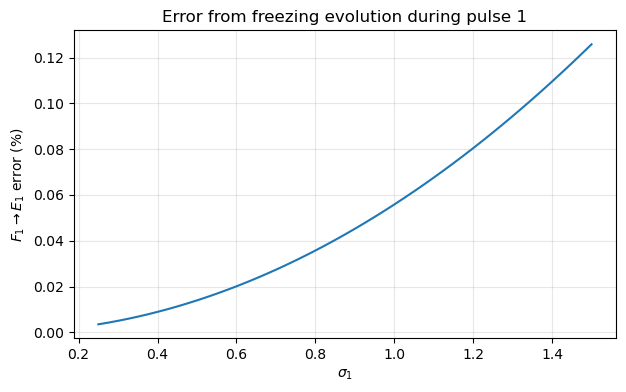

In [87]:
plt.figure(figsize=(7, 4))

plt.plot(
    sigma1_values,
    100 * err_frozen_sigma1,
)

plt.xlabel(r"$\sigma_1$")
plt.ylabel(r"$F_1 \rightarrow E_1$ error (%)")

plt.title(
    r"Error from freezing evolution during pulse 1"
)

plt.grid(alpha=0.3)

plt.show()

In [88]:
# ============================================================
# Coherent prepared state for testing the importance of F1
# ============================================================

eg = model["eg"]

psi_coh = (
    gg + eg
) / np.sqrt(2.0)

rho_coh = np.outer(
    psi_coh,
    psi_coh.conj(),
)

rho_coh_vec = rho_coh.reshape(
    -1,
    order="F",
)


print("Coherent prepared state:")
print(rho_coh)

print("\nTrace:")
print(np.trace(rho_coh))

print("\nLiouvillian drift norms:")

print(
    "||L rho_g||   =",
    norm(L_super @ rho_g_vec)
)

print(
    "||L rho_coh|| =",
    norm(L_super @ rho_coh_vec)
)

Coherent prepared state:
[[0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

Trace:
(0.9999999999999998+0j)

Liouvillian drift norms:
||L rho_g||   = 0.006123724356957946
||L rho_coh|| = 0.7153386435807866


In [89]:
# ============================================================
# Coherent prepared state
#
# |psi> = (|gg> + |eg>) / sqrt(2)
# ============================================================

eg = model["eg"]

psi_coh = (
    gg + eg
) / np.sqrt(2.0)

rho_coh = np.outer(
    psi_coh,
    psi_coh.conj(),
)

rho_coh_vec = rho_coh.reshape(
    -1,
    order="F",
)


print("Coherent prepared state:")
print(rho_coh)

print("\nTrace:")
print(np.trace(rho_coh))

print("\nLiouvillian drift norms:")

print(
    "||L rho_g||   =",
    norm(L_super @ rho_g_vec)
)

print(
    "||L rho_coh|| =",
    norm(L_super @ rho_coh_vec)
)

print(
    "\nRatio =",
    norm(L_super @ rho_coh_vec)
    / norm(L_super @ rho_g_vec)
)

Coherent prepared state:
[[0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

Trace:
(0.9999999999999998+0j)

Liouvillian drift norms:
||L rho_g||   = 0.006123724356957946
||L rho_coh|| = 0.7153386435807866

Ratio = 116.81431133783788


In [90]:
# ============================================================
# Coherent preparation:
# full F1 versus frozen E1 during pulse 1
# ============================================================

tau_prep_coh = 4.0
sigma1_coh = 0.5


# State at the center of pulse 1
rho_coh_center_vec = (
    expm(L_super * tau_prep_coh)
    @ rho_coh_vec
)


# Pulse-1 operators
F1_coh = F_gaussian_eta(
    w1,
    +1,
    sigma1_coh,
    pulse=1,
)

E1_coh = E_spectrum_eta(
    w1,
    +1,
    sigma1_coh,
)


# Full treatment:
# F1 exp(L tau_prep) rho_coh
A_coh_F1 = finish_NR_from_first_pulse_state(
    F1_coh @ rho_coh_center_vec
)


# Frozen during pulse 1:
# E1 exp(L tau_prep) rho_coh
A_coh_E1 = finish_NR_from_first_pulse_state(
    E1_coh * rho_coh_center_vec
)


F1_coh_correction = (
    abs(A_coh_E1 - A_coh_F1)
    / abs(A_coh_F1)
)


print("tau_prep =", tau_prep_coh)
print("sigma1   =", sigma1_coh)

print("\nState drift at pulse-1 center:")
print(
    "||L rho_center|| =",
    norm(L_super @ rho_coh_center_vec)
)

print("\nFull coherent F1 result:")
print(A_coh_F1)
print("|A| =", abs(A_coh_F1))

print("\nFrozen coherent E1 result:")
print(A_coh_E1)
print("|A| =", abs(A_coh_E1))

print("\nIntrinsic F1 -> E1 error:")
print(F1_coh_correction)

print(
    "Intrinsic F1 -> E1 error (%) =",
    100 * F1_coh_correction
)

tau_prep = 4.0
sigma1   = 0.5

State drift at pulse-1 center:
||L rho_center|| = 0.6343146524326648

Full coherent F1 result:
(-12.645985378089524-173.72328871828523j)
|A| = 174.1829555073617

Frozen coherent E1 result:
(-12.807019960201888-173.7401006259689j)
|A| = 174.21148735311002

Intrinsic F1 -> E1 error:
0.0009295385968109968
Intrinsic F1 -> E1 error (%) = 0.09295385968109968


In [91]:
# ============================================================
# Coherent-state pulse-1 width scan
#
# tau_prep fixed at 4
# sigma2 = sigma3 = 0.5 remain unchanged
# ============================================================

sigma1_coh_values = np.linspace(
    0.10,
    0.50,
    41,
)

A_coh_F1_scan = np.empty(
    len(sigma1_coh_values),
    dtype=complex,
)

A_coh_E1_scan = np.empty(
    len(sigma1_coh_values),
    dtype=complex,
)

err_coh_F1_scan = np.empty(
    len(sigma1_coh_values)
)


for i, sigma1_test in enumerate(sigma1_coh_values):

    F1_test = F_gaussian_eta(
        w1,
        +1,
        sigma1_test,
        pulse=1,
    )

    E1_test = E_spectrum_eta(
        w1,
        +1,
        sigma1_test,
    )

    A_coh_F1_scan[i] = (
        finish_NR_from_first_pulse_state(
            F1_test @ rho_coh_center_vec
        )
    )

    A_coh_E1_scan[i] = (
        finish_NR_from_first_pulse_state(
            E1_test * rho_coh_center_vec
        )
    )

    err_coh_F1_scan[i] = (
        abs(
            A_coh_E1_scan[i]
            - A_coh_F1_scan[i]
        )
        / abs(A_coh_F1_scan[i])
    )


print("sigma1 = 0.10:")
print(
    "F1 -> E1 error (%) =",
    100 * err_coh_F1_scan[0]
)

print("\nsigma1 = 0.50:")
print(
    "F1 -> E1 error (%) =",
    100 * err_coh_F1_scan[-1]
)

sigma1 = 0.10:
F1 -> E1 error (%) = 0.003712094132176304

sigma1 = 0.50:
F1 -> E1 error (%) = 0.09295385968109968


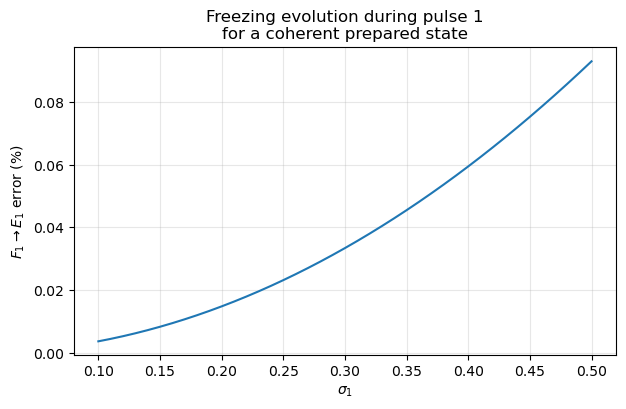

In [92]:
plt.figure(figsize=(7, 4))

plt.plot(
    sigma1_coh_values,
    100 * err_coh_F1_scan,
)

plt.xlabel(r"$\sigma_1$")
plt.ylabel(r"$F_1 \rightarrow E_1$ error (%)")

plt.title(
    "Freezing evolution during pulse 1\n"
    "for a coherent prepared state"
)

plt.grid(alpha=0.3)

plt.show()

In [93]:
# ============================================================
# State-level F1 correction versus final-signal correction
# ============================================================

x_F1_coh = F1_coh @ rho_coh_center_vec
x_E1_coh = E1_coh * rho_coh_center_vec

state_level_error = (
    norm(x_E1_coh - x_F1_coh)
    / norm(x_F1_coh)
)

signal_level_error = (
    abs(A_coh_E1 - A_coh_F1)
    / abs(A_coh_F1)
)

print("State-level F1 -> E1 difference:")
print(state_level_error)
print("Percent =", 100 * state_level_error)

print("\nFinal-signal F1 -> E1 difference:")
print(signal_level_error)
print("Percent =", 100 * signal_level_error)

State-level F1 -> E1 difference:
0.08660956857240522
Percent = 8.660956857240523

Final-signal F1 -> E1 difference:
0.0009295385968109968
Percent = 0.09295385968109968


In [94]:
# ============================================================
# Scan pairwise coherent prepared states
#
# |psi_ij> = (|i> + |j>) / sqrt(2)
#
# tau_prep = 4
# sigma1   = 0.5
# ============================================================

basis_states = {
    "gg": model["gg"],
    "eg": model["eg"],
    "ge": model["ge"],
    "ee": model["ee"],
}

tau_test = 4.0
sigma1_test = 0.5

F1_test = F_gaussian_eta(
    w1,
    +1,
    sigma1_test,
    pulse=1,
)

E1_test = E_spectrum_eta(
    w1,
    +1,
    sigma1_test,
)

results_coherent_states = []

names = list(basis_states.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):

        name_i = names[i]
        name_j = names[j]

        ket_i = basis_states[name_i]
        ket_j = basis_states[name_j]

        psi = (
            ket_i + ket_j
        ) / np.sqrt(2.0)

        rho = np.outer(
            psi,
            psi.conj(),
        )

        rho_vec = rho.reshape(
            -1,
            order="F",
        )

        rho_center = (
            expm(L_super * tau_test)
            @ rho_vec
        )

        x_F1 = F1_test @ rho_center
        x_E1 = E1_test * rho_center

        A_F1 = finish_NR_from_first_pulse_state(
            x_F1
        )

        A_E1 = finish_NR_from_first_pulse_state(
            x_E1
        )

        state_error = (
            norm(x_E1 - x_F1)
            / norm(x_F1)
        )

        signal_error = (
            abs(A_E1 - A_F1)
            / abs(A_F1)
        )

        drift = norm(
            L_super @ rho_center
        )

        results_coherent_states.append(
            (
                f"{name_i}+{name_j}",
                drift,
                state_error,
                signal_error,
                abs(A_F1),
            )
        )


# Sort by largest final-signal F1 correction
results_coherent_states.sort(
    key=lambda x: x[3],
    reverse=True,
)


print(
    f"{'state':10s} "
    f"{'||Lrho||':>12s} "
    f"{'state err %':>14s} "
    f"{'signal err %':>15s} "
    f"{'|A_F1|':>12s}"
)

print("-" * 70)

for (
    name,
    drift,
    state_error,
    signal_error,
    amplitude,
) in results_coherent_states:

    print(
        f"{name:10s} "
        f"{drift:12.6f} "
        f"{100*state_error:14.6f} "
        f"{100*signal_error:15.6f} "
        f"{amplitude:12.6f}"
    )

state          ||Lrho||    state err %    signal err %       |A_F1|
----------------------------------------------------------------------
gg+ee          1.249457      37.332636       57.085109    69.192915
eg+ee          0.640414      12.171006        1.806532    11.436701
eg+ge          0.128362       0.757949        0.568196   140.155260
gg+ge          0.758782      12.103435        0.541196    77.117694
ge+ee          0.536586       8.733005        0.446996   102.563697
gg+eg          0.634315       8.660957        0.092954   174.182956


In [95]:
# ============================================================
# Double-quantum coherent preparation:
#
# |psi> = (|gg> + |ee>) / sqrt(2)
#
# Re-evaluate at tau_prep = 12 so the later negative-delay
# ODE scan is physically well defined.
# ============================================================

ee = model["ee"]

psi_gg_ee = (
    gg + ee
) / np.sqrt(2.0)

rho_gg_ee = np.outer(
    psi_gg_ee,
    psi_gg_ee.conj(),
)

rho_gg_ee_vec = rho_gg_ee.reshape(
    -1,
    order="F",
)


tau_prep_gg_ee = 12.0
sigma1_gg_ee = 0.5


# State at pulse-1 center
rho_gg_ee_center_vec = (
    expm(L_super * tau_prep_gg_ee)
    @ rho_gg_ee_vec
)


# Pulse-1 operators
F1_gg_ee = F_gaussian_eta(
    w1,
    +1,
    sigma1_gg_ee,
    pulse=1,
)

E1_gg_ee = E_spectrum_eta(
    w1,
    +1,
    sigma1_gg_ee,
)


# Full F1 treatment
A_gg_ee_F1 = finish_NR_from_first_pulse_state(
    F1_gg_ee @ rho_gg_ee_center_vec
)


# Frozen pulse-1 approximation
A_gg_ee_E1 = finish_NR_from_first_pulse_state(
    E1_gg_ee * rho_gg_ee_center_vec
)


err_gg_ee = (
    abs(A_gg_ee_E1 - A_gg_ee_F1)
    / abs(A_gg_ee_F1)
)


print("tau_prep =", tau_prep_gg_ee)

print("\n||L rho at pulse-1 center||:")
print(
    norm(
        L_super @ rho_gg_ee_center_vec
    )
)

print("\nFull F1 result:")
print(A_gg_ee_F1)
print("|A| =", abs(A_gg_ee_F1))

print("\nFrozen E1 result:")
print(A_gg_ee_E1)
print("|A| =", abs(A_gg_ee_E1))

print("\nF1 -> E1 error:")
print(err_gg_ee)

print(
    "F1 -> E1 error (%) =",
    100 * err_gg_ee
)

tau_prep = 12.0

||L rho at pulse-1 center||:
0.8044977060712198

Full F1 result:
(-43.54651197785148-133.54365172334582j)
|A| = 140.46425033097725

Frozen E1 result:
(-67.72766033147234-132.42953651653468j)
|A| = 148.74346411173664

F1 -> E1 error:
0.1723342444825445
F1 -> E1 error (%) = 17.23342444825445


In [96]:
# ============================================================
# Generic explicit ODE for an arbitrary prepared state
# ============================================================

def ode_NR_arbitrary_prepared(
    t1_delay,
    sigma_test,
    T_test,
    tau_prep,
    rho_prep_vec,
):

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_test

    t_prep = -tau_prep

    n = d * d

    t_start = t_prep
    t_end = max(
        tau1,
        tau2,
        tau3,
    ) + 8.0 * sigma_test


    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]

        E1 = gaussian_component_sigma(
            t,
            tau1,
            +1,
            sigma_test,
        )

        E2 = gaussian_component_sigma(
            t,
            tau2,
            -1,
            sigma_test,
        )

        E3 = gaussian_component_sigma(
            t,
            tau3,
            +1,
            sigma_test,
        )


        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )


        detection_weight = np.exp(
            (1j * w3 - eta)
            * (t - tau3)
        )

        dz = (
            detection_weight
            * (mu_bra @ rho123)
        )


        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])


    y0 = np.concatenate([
        rho_prep_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])


    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)


    rho123_end = sol.y[
        3*n:4*n,
        -1
    ]

    signal = sol.y[
        -1,
        -1
    ]

    v_end = t_end - tau3


    tail = (
        np.exp(
            (1j * w3 - eta) * v_end
        )
        * (
            mu_bra
            @ apply_G(
                w3,
                rho123_end,
            )
        )
    )


    return signal + tail

In [97]:
# ============================================================
# One-delay sanity check for |gg> + |ee> preparation
# ============================================================

S_gg_ee_test = ode_NR_arbitrary_prepared(
    t1_delay=10.0,
    sigma_test=0.5,
    T_test=10.0,
    tau_prep=tau_prep_gg_ee,
    rho_prep_vec=rho_gg_ee_vec,
)

print("gg+ee prepared-state ODE at t1 = 10:")
print(S_gg_ee_test)
print("|S| =", abs(S_gg_ee_test))

gg+ee prepared-state ODE at t1 = 10:
(-0.41518297073186994-6.169988237685558j)
|S| = 6.183941441537418


In [98]:
# ============================================================
# Full ODE benchmark for the |gg> + |ee> coherent preparation
# ============================================================

t1_gg_ee_fine = np.arange(
    -8.0,
    8.0 + 0.25,
    0.25,
)

t1_gg_ee_tail = np.arange(
    9.0,
    300.0 + 1.0,
    1.0,
)

t1_gg_ee_grid = np.concatenate([
    t1_gg_ee_fine,
    t1_gg_ee_tail,
])


S_gg_ee = np.empty(
    len(t1_gg_ee_grid),
    dtype=complex,
)


print(
    "Number of gg+ee ODE calculations:",
    len(t1_gg_ee_grid),
)


for i, t1_delay in enumerate(
    t1_gg_ee_grid
):

    S_gg_ee[i] = (
        ode_NR_arbitrary_prepared(
            t1_delay=t1_delay,
            sigma_test=0.5,
            T_test=10.0,
            tau_prep=tau_prep_gg_ee,
            rho_prep_vec=rho_gg_ee_vec,
        )
    )

    if i % 30 == 0:
        print(
            f"{i:4d} / "
            f"{len(t1_gg_ee_grid)-1:4d}   "
            f"t1 = {t1_delay:8.2f}"
        )


weight_gg_ee = np.exp(
    (1j * w1 - eta)
    * t1_gg_ee_grid
)


A_gg_ee_ODE = np.trapezoid(
    weight_gg_ee * S_gg_ee,
    t1_gg_ee_grid,
)


err_ODE_F1_gg_ee = (
    abs(
        A_gg_ee_ODE
        - A_gg_ee_F1
    )
    / abs(A_gg_ee_ODE)
)


err_ODE_E1_gg_ee = (
    abs(
        A_gg_ee_ODE
        - A_gg_ee_E1
    )
    / abs(A_gg_ee_ODE)
)


print("\n====================================")

print("Explicit ODE:")
print(A_gg_ee_ODE)
print("|A| =", abs(A_gg_ee_ODE))


print("\nFull F1 prediction:")
print(A_gg_ee_F1)
print("|A| =", abs(A_gg_ee_F1))


print("\nFrozen E1 prediction:")
print(A_gg_ee_E1)
print("|A| =", abs(A_gg_ee_E1))


print("\n------------------------------------")

print("ODE vs full F1 error:")
print(err_ODE_F1_gg_ee)
print(
    "Percent =",
    100 * err_ODE_F1_gg_ee,
)


print("\nODE vs frozen E1 error:")
print(err_ODE_E1_gg_ee)
print(
    "Percent =",
    100 * err_ODE_E1_gg_ee,
)


print("\nIntrinsic F1 -> E1 difference:")
print(
    abs(A_gg_ee_E1 - A_gg_ee_F1)
    / abs(A_gg_ee_F1)
)

Number of gg+ee ODE calculations: 357
   0 /  356   t1 =    -8.00
  30 /  356   t1 =    -0.50
  60 /  356   t1 =     7.00
  90 /  356   t1 =    34.00
 120 /  356   t1 =    64.00
 150 /  356   t1 =    94.00
 180 /  356   t1 =   124.00
 210 /  356   t1 =   154.00
 240 /  356   t1 =   184.00
 270 /  356   t1 =   214.00
 300 /  356   t1 =   244.00
 330 /  356   t1 =   274.00

Explicit ODE:
(-43.57684189097715-133.8800010710743j)
|A| = 140.79345096978793

Full F1 prediction:
(-43.54651197785148-133.54365172334582j)
|A| = 140.46425033097725

Frozen E1 prediction:
(-67.72766033147234-132.42953651653468j)
|A| = 148.74346411173664

------------------------------------
ODE vs full F1 error:
0.00239864893709697
Percent = 0.23986489370969702

ODE vs frozen E1 error:
0.1718427633434813
Percent = 17.18427633434813

Intrinsic F1 -> E1 difference:
0.1723342444825445


### Validation of the first-pulse Liouvillian filter \(F_1\)

To test the general prepared-state formulation, we used the coherent initial state

$$
|\psi_{\mathrm{prep}}\rangle
=
\frac{|gg\rangle+|ee\rangle}{\sqrt{2}},
$$

with

$$
\rho_{\mathrm{prep}}
=
|\psi_{\mathrm{prep}}\rangle
\langle\psi_{\mathrm{prep}}|,
\qquad
\tau_{\mathrm{prep}}=12,
\qquad
\sigma_1=\sigma_2=\sigma_3=0.5,
\qquad
T=10.
$$

The full finite-width frequency-domain expression uses

$$
F_1^{(+)}
e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

The explicit perturbative ODE calculation gave

$$
A_{\mathrm{ODE}}
=
-43.5768-133.8800i,
$$

while the full \(F_1F_2F_3\) frequency-domain calculation gave

$$
A_{F_1}
=
-43.5465-133.5437i,
$$

corresponding to a relative difference of

$$
0.240\%.
$$

In contrast, replacing the first-pulse operator by the frozen-state
scalar approximation,

$$
F_1^{(+)}
\rightarrow
E_1^{(+)},
$$

gave

$$
A_{E_1}
=
-67.7277-132.4295i,
$$

which differs from the explicit ODE by

$$
17.18\%.
$$

Thus, for a dynamically evolving prepared state, the operator-valued
first-pulse filter \(F_1\) is required to reproduce the explicit
finite-pulse dynamics. The frozen \(E_1\) approximation can fail even
when the pulse width itself is moderate.

### Four-level comparison for a dynamically evolving prepared state

We now separate the two approximations associated with the state before
and during pulse 1.

The prepared state is

$$
|\psi_{\mathrm{prep}}\rangle
=
\frac{|gg\rangle+|ee\rangle}{\sqrt{2}},
$$

with

$$
\rho_{\mathrm{prep}}
=
|\psi_{\mathrm{prep}}\rangle
\langle\psi_{\mathrm{prep}}|,
\qquad
\tau_{\mathrm{prep}}=12,
\qquad
\sigma_1=\sigma_2=\sigma_3=0.5,
\qquad
T=10.
$$

Four frequency-domain treatments are compared with the same explicit
perturbative ODE calculation:

$$
\text{Full:}
\qquad
F_1 e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle,
$$

$$
\text{Frozen during pulse 1:}
\qquad
E_1 e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle,
$$

$$
\text{Frozen preparation delay:}
\qquad
F_1
|\rho_{\mathrm{prep}}\rangle\rangle,
$$

and

$$
\text{Fully frozen:}
\qquad
E_1
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

This comparison independently tests the importance of evolution during
the preparation interval and evolution across the finite duration of
pulse 1.

In [99]:
# ============================================================
# Four-way comparison for the |gg> + |ee> prepared state
# ============================================================

# ------------------------------------------------------------
# 1. Full:
# F1 exp(L tau_prep) rho_prep
# ------------------------------------------------------------

A_gg_ee_full = finish_NR_from_first_pulse_state(
    F1_gg_ee @ rho_gg_ee_center_vec
)


# ------------------------------------------------------------
# 2. Frozen during pulse 1:
# E1 exp(L tau_prep) rho_prep
# ------------------------------------------------------------

A_gg_ee_frozen_width = finish_NR_from_first_pulse_state(
    E1_gg_ee * rho_gg_ee_center_vec
)


# ------------------------------------------------------------
# 3. Frozen preparation delay:
# F1 rho_prep
# ------------------------------------------------------------

A_gg_ee_frozen_delay = finish_NR_from_first_pulse_state(
    F1_gg_ee @ rho_gg_ee_vec
)


# ------------------------------------------------------------
# 4. Fully frozen:
# E1 rho_prep
# ------------------------------------------------------------

A_gg_ee_fully_frozen = finish_NR_from_first_pulse_state(
    E1_gg_ee * rho_gg_ee_vec
)


# ------------------------------------------------------------
# Collect and compare with the SAME explicit ODE
# ------------------------------------------------------------

comparison_gg_ee = {
    "Explicit ODE":
        A_gg_ee_ODE,

    "Full: F1 exp(L tau_prep) rho_prep":
        A_gg_ee_full,

    "Frozen pulse width: E1 exp(L tau_prep) rho_prep":
        A_gg_ee_frozen_width,

    "Frozen prep delay: F1 rho_prep":
        A_gg_ee_frozen_delay,

    "Fully frozen: E1 rho_prep":
        A_gg_ee_fully_frozen,
}


print("============================================")
print("FOUR-WAY PREPARED-STATE COMPARISON")
print("============================================\n")

for name, value in comparison_gg_ee.items():

    print(name)
    print("  A =", value)
    print("  |A| =", abs(value))

    if name != "Explicit ODE":

        err = (
            abs(value - A_gg_ee_ODE)
            / abs(A_gg_ee_ODE)
        )

        print(
            "  relative error vs ODE =",
            err
        )

        print(
            "  percent error vs ODE =",
            100 * err
        )

    print()


# ------------------------------------------------------------
# Also isolate the two approximation effects directly
# ------------------------------------------------------------

width_effect = (
    abs(
        A_gg_ee_frozen_width
        - A_gg_ee_full
    )
    / abs(A_gg_ee_full)
)

prep_effect = (
    abs(
        A_gg_ee_frozen_delay
        - A_gg_ee_full
    )
    / abs(A_gg_ee_full)
)

fully_frozen_effect = (
    abs(
        A_gg_ee_fully_frozen
        - A_gg_ee_full
    )
    / abs(A_gg_ee_full)
)


print("============================================")
print("INTRINSIC APPROXIMATION EFFECTS")
print("============================================")

print(
    "F1 -> E1 only:",
    100 * width_effect,
    "%"
)

print(
    "exp(L tau_prep) -> I only:",
    100 * prep_effect,
    "%"
)

print(
    "Both approximations together:",
    100 * fully_frozen_effect,
    "%"
)

FOUR-WAY PREPARED-STATE COMPARISON

Explicit ODE
  A = (-43.57684189097715-133.8800010710743j)
  |A| = 140.79345096978793

Full: F1 exp(L tau_prep) rho_prep
  A = (-43.54651197785148-133.54365172334582j)
  |A| = 140.46425033097725
  relative error vs ODE = 0.00239864893709697
  percent error vs ODE = 0.23986489370969702

Frozen pulse width: E1 exp(L tau_prep) rho_prep
  A = (-67.72766033147234-132.42953651653468j)
  |A| = 148.74346411173664
  relative error vs ODE = 0.1718427633434813
  percent error vs ODE = 17.18427633434813

Frozen prep delay: F1 rho_prep
  A = (-39.96096137106963-180.33868333499925j)
  |A| = 184.71307246835903
  relative error vs ODE = 0.3309754930706931
  percent error vs ODE = 33.097549307069315

Fully frozen: E1 rho_prep
  A = (-52.87824101284677-225.86653411240127j)
  |A| = 231.97370455411803
  relative error vs ODE = 0.6566754424152156
  percent error vs ODE = 65.66754424152155

INTRINSIC APPROXIMATION EFFECTS
F1 -> E1 only: 17.23342444825445 %
exp(L tau_prep)

### Prepared-state validation and breakdown of frozen-state approximations

We now compare the full finite-width prepared-state expression with
several increasingly restrictive approximations.

The prepared state is the coherent superposition

$$
|\psi_{\mathrm{prep}}\rangle
=
\frac{|gg\rangle+|ee\rangle}{\sqrt{2}},
$$

with

$$
\rho_{\mathrm{prep}}
=
|\psi_{\mathrm{prep}}\rangle
\langle\psi_{\mathrm{prep}}|,
$$

and parameters

$$
\tau_{\mathrm{prep}}=12,
\qquad
\sigma_1=\sigma_2=\sigma_3=0.5,
\qquad
T=10.
$$

The full finite-width treatment contains both the field-free evolution
between preparation and pulse 1,

$$
e^{\mathcal L\tau_{\mathrm{prep}}},
$$

and the operator-valued first-pulse filter,

$$
F_1.
$$

The complete first-pulse preparation factor is therefore

$$
F_1
e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

The explicit perturbative ODE calculation gives

$$
A_{\mathrm{ODE}}
=
-43.5768-133.8800i,
$$

with

$$
|A_{\mathrm{ODE}}|
=
140.7935.
$$

The full frequency-domain result is

$$
A_{\mathrm{full}}
=
-43.5465-133.5437i,
$$

which differs from the explicit ODE by only

$$
\boxed{0.240\%}.
$$

This establishes that the full operator expression

$$
F_1
e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle
$$

accurately reproduces the explicitly propagated finite-pulse dynamics.

We then compare three frozen-state approximations.

#### 1. Freeze evolution during pulse 1

Replacing

$$
F_1
\rightarrow
E_1
$$

while retaining the preparation evolution gives

$$
E_1
e^{\mathcal L\tau_{\mathrm{prep}}}
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

The resulting amplitude is

$$
A
=
-67.7277-132.4295i,
$$

with an error relative to the explicit ODE of

$$
\boxed{17.18\%}.
$$

The intrinsic change relative to the full frequency-domain result is

$$
17.23\%.
$$

Thus, for this dynamically evolving coherent preparation, the
operator-valued nature of \(F_1\) is essential.

#### 2. Freeze the preparation-to-pulse evolution

Retaining \(F_1\) but replacing

$$
e^{\mathcal L\tau_{\mathrm{prep}}}
\rightarrow I
$$

gives

$$
F_1
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

The resulting amplitude is

$$
A
=
-39.9610-180.3387i,
$$

with an error relative to the explicit ODE of

$$
\boxed{33.10\%}.
$$

The intrinsic change relative to the full result is

$$
33.41\%.
$$

Therefore, field-free evolution between state preparation and the
arrival of pulse 1 can be even more important than evolution during
the pulse itself.

#### 3. Freeze both effects

Finally, replacing both

$$
F_1\rightarrow E_1
$$

and

$$
e^{\mathcal L\tau_{\mathrm{prep}}}\rightarrow I
$$

gives

$$
E_1
|\rho_{\mathrm{prep}}\rangle\rangle.
$$

This produces

$$
A
=
-52.8782-225.8665i,
$$

with an error relative to the explicit ODE of

$$
\boxed{65.67\%}.
$$

The intrinsic change relative to the full frequency-domain result is

$$
66.06\%.
$$

The two approximations are not additive because they modify different
Liouvillian components of the prepared density matrix before those
components propagate through the subsequent nonlinear response.

Overall, the comparison establishes the hierarchy

$$
\boxed{
F_1e^{\mathcal L\tau_{\mathrm{prep}}}
\quad\text{full treatment}
}
$$

$$
\Downarrow
$$

$$
\boxed{
0.24\%\ \text{error relative to the explicit ODE}
}
$$

whereas neglecting evolution during pulse 1, neglecting evolution
during the preparation delay, or neglecting both produces errors of

$$
\boxed{
17.18\%,\qquad
33.10\%,\qquad
65.67\%
}
$$

respectively.

This demonstrates that for nonstationary prepared states the
first-pulse dynamics cannot, in general, be represented by a scalar
laser spectrum alone. Both the preparation propagator
\(e^{\mathcal L\tau_{\mathrm{prep}}}\) and the operator-valued pulse
filter \(F_1\) may be required.

# Rephasing finite-width response

We now validate the finite-width formalism for the rephasing field
signature

$$
(s_1,s_2,s_3)=(-,+,+).
$$

The corresponding pulse operators are

$$
F_1^{(-)},\qquad
F_2^{(+)},\qquad
F_3^{(+)}.
$$

For the rephasing branch, the first coherence frequency is represented
by a signed negative frequency,

$$
\nu_1<0.
$$

We choose

$$
\nu_1=-\Omega_+,
\qquad
\omega_3=+\Omega_+.
$$

The finite-width full-\(V\) response is

$$
A_{\mathrm{R,finite}}
=
\langle\!\langle\mu|
G(\omega_3)
V
e^{\mathcal LT}
F_3^{(+)}
F_2^{(+)}
V
G(\nu_1)
V
F_1^{(-)}
|\rho\rangle\rangle.
$$

No molecular rotating-wave approximation is imposed in this
finite-width expression. The field-sign sequence selects the rephasing
branch, while every molecular interaction retains the full
commutator superoperator \(V\).

For numerical comparisons we use

$$
\sigma_1=\sigma_2=\sigma_3=0.5,
\qquad
T=10,
\qquad
\eta=0.02.
$$

In [100]:
# ============================================================
# Rephasing branch: frequencies and impulsive references
# ============================================================

nu1_R = -omega_plus
w3_R = +omega_plus

sigma_R = 0.5
T_R = 10.0

prop_T_R = expm(
    L_super * T_R
)


# ------------------------------------------------------------
# RWA-resolved impulsive rephasing response
#
# first interaction:  V_down
# second interaction: V_up
# third interaction:  V_up
# ------------------------------------------------------------

x = V_down @ rho_ss_vec

x = apply_G(
    nu1_R,
    x,
)

x = V_up @ x

x = prop_T_R @ x

x = V_up @ x

x = apply_G(
    w3_R,
    x,
)

M_R_RWA = mu_bra @ x


# ------------------------------------------------------------
# Full-V impulsive response at the same signed frequencies
# ------------------------------------------------------------

x = V @ rho_ss_vec

x = apply_G(
    nu1_R,
    x,
)

x = V @ x

x = prop_T_R @ x

x = V @ x

x = apply_G(
    w3_R,
    x,
)

M_R_full = mu_bra @ x


print("nu1_R =", nu1_R)
print("w3_R  =", w3_R)

print("\nImpulsive RWA rephasing:")
print(M_R_RWA)
print("|M| =", abs(M_R_RWA))

print("\nImpulsive full-V:")
print(M_R_full)
print("|M| =", abs(M_R_full))

print("\nRelative full-V / RWA difference:")
print(
    abs(M_R_full - M_R_RWA)
    / abs(M_R_RWA)
)

nu1_R = -1.2414213562373095
w3_R  = 1.2414213562373095

Impulsive RWA rephasing:
(-152.7726949661823-1180.029430287123j)
|M| = 1189.8777049222253

Impulsive full-V:
(-183.4145751922395-1180.2643268652162j)
|M| = 1194.4307379097172

Relative full-V / RWA difference:
0.0257528823584396


In [101]:
# ============================================================
# Rephasing finite-width pulse operators
#
# field signature = (-, +, +)
# ============================================================

F1_R_eta = F_gaussian_eta(
    nu1_R,
    -1,
    sigma_R,
    pulse=1,
)

F2_R_eta = F_gaussian_eta(
    nu1_R,
    +1,
    sigma_R,
    pulse=2,
)

F3_R_eta = F_gaussian_eta(
    w3_R,
    +1,
    sigma_R,
    pulse=3,
)


print("Finite-width rephasing operator norms:")

print(
    "||F1_R|| =",
    norm(F1_R_eta)
)

print(
    "||F2_R|| =",
    norm(F2_R_eta)
)

print(
    "||F3_R|| =",
    norm(F3_R_eta)
)

Finite-width rephasing operator norms:
||F1_R|| = 2.2103059522835027
||F2_R|| = 2.2103059522835027
||F3_R|| = 2.2103059522835027


In [102]:
# ============================================================
# Stationary-state finite-width rephasing response
# ============================================================

x = F1_R_eta @ rho_ss_vec

x = V @ x

x = apply_G(
    nu1_R,
    x,
)

x = V @ x

x = F2_R_eta @ x
x = F3_R_eta @ x

x = prop_T_R @ x

x = V @ x

x = apply_G(
    w3_R,
    x,
)

A_R_finite_ss = mu_bra @ x


print("Finite-width rephasing response:")
print(A_R_finite_ss)
print("|A| =", abs(A_R_finite_ss))


# ------------------------------------------------------------
# Stationary-state reduction of F1
#
# At finite eta the scalar pulse factor must use the same
# eta-weighted spectrum.
# ------------------------------------------------------------

E1_R_eta = E_spectrum_eta(
    nu1_R,
    -1,
    sigma_R,
)

x = E1_R_eta * rho_ss_vec

x = V @ x
x = apply_G(nu1_R, x)

x = V @ x

x = F2_R_eta @ x
x = F3_R_eta @ x

x = prop_T_R @ x

x = V @ x
x = apply_G(w3_R, x)

A_R_finite_ss_reduced = mu_bra @ x


print("\nStationary reduced E1 F2 F3:")
print(A_R_finite_ss_reduced)

print("\nRelative full-F1 vs reduced-E1 difference:")
print(
    abs(
        A_R_finite_ss
        - A_R_finite_ss_reduced
    )
    / abs(A_R_finite_ss)
)

Finite-width rephasing response:
(-46.05297358915912-288.15931443585214j)
|A| = 291.81615252165886

Stationary reduced E1 F2 F3:
(-46.05297358915912-288.15931443585214j)

Relative full-F1 vs reduced-E1 difference:
0.0


In [103]:
# ============================================================
# Explicit finite-pulse ODE for the rephasing branch
#
# Field signature:
#   (-, +, +)
#
# First Fourier frequency:
#   nu1_R < 0
# ============================================================

def ode_R_at_t1_sigma_T(
    t1_delay,
    sigma_test,
    T_test,
    rho0_vec=rho_ss_vec,
):

    tau1 = 0.0
    tau2 = t1_delay
    tau3 = t1_delay + T_test

    n = d * d

    # Stationary initial state, so we can begin before
    # whichever pulse occurs first.
    t_start = min(
        tau1,
        tau2,
        tau3,
    ) - 8.0 * sigma_test

    t_end = max(
        tau1,
        tau2,
        tau3,
    ) + 8.0 * sigma_test


    def rhs(t, y):

        rho0   = y[0*n:1*n]
        rho1   = y[1*n:2*n]
        rho12  = y[2*n:3*n]
        rho123 = y[3*n:4*n]


        # Rephasing field signature (-, +, +)
        E1 = gaussian_component_sigma(
            t,
            tau1,
            -1,
            sigma_test,
        )

        E2 = gaussian_component_sigma(
            t,
            tau2,
            +1,
            sigma_test,
        )

        E3 = gaussian_component_sigma(
            t,
            tau3,
            +1,
            sigma_test,
        )


        drho0 = L_super @ rho0

        drho1 = (
            L_super @ rho1
            + E1 * (V @ rho0)
        )

        drho12 = (
            L_super @ rho12
            + E2 * (V @ rho1)
        )

        drho123 = (
            L_super @ rho123
            + E3 * (V @ rho12)
        )


        detection_weight = np.exp(
            (1j * w3_R - eta)
            * (t - tau3)
        )

        dz = (
            detection_weight
            * (mu_bra @ rho123)
        )


        return np.concatenate([
            drho0,
            drho1,
            drho12,
            drho123,
            np.array([dz]),
        ])


    y0 = np.concatenate([
        rho0_vec,
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(n, dtype=complex),
        np.zeros(1, dtype=complex),
    ])


    sol = solve_ivp(
        rhs,
        (t_start, t_end),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(sol.message)


    rho123_end = sol.y[
        3*n:4*n,
        -1
    ]

    signal = sol.y[
        -1,
        -1
    ]

    v_end = t_end - tau3


    # Analytic detection-time tail
    tail = (
        np.exp(
            (1j * w3_R - eta) * v_end
        )
        * (
            mu_bra
            @ apply_G(
                w3_R,
                rho123_end,
            )
        )
    )


    return signal + tail

In [104]:
# ============================================================
# One-delay sanity check
# ============================================================

S_R_test = ode_R_at_t1_sigma_T(
    t1_delay=10.0,
    sigma_test=sigma_R,
    T_test=T_R,
    rho0_vec=rho_ss_vec,
)

print("Rephasing ODE at t1 = 10:")
print(S_R_test)
print("|S| =", abs(S_R_test))

Rephasing ODE at t1 = 10:
(-3.1089266642541205-10.66026229813232j)
|S| = 11.104351276355212


In [106]:
# ============================================================
# Rephasing finite-pulse ODE -> frequency domain
# ============================================================

t1_R_fine = np.arange(
    -8.0,
    8.0 + 0.25,
    0.25,
)

t1_R_tail = np.arange(
    9.0,
    300.0 + 1.0,
    1.0,
)

t1_R_grid = np.concatenate([
    t1_R_fine,
    t1_R_tail,
])


S_R = np.empty(
    len(t1_R_grid),
    dtype=complex,
)


print(
    "Number of rephasing ODE calculations:",
    len(t1_R_grid),
)


for i, t1_delay in enumerate(
    t1_R_grid
):

    S_R[i] = ode_R_at_t1_sigma_T(
        t1_delay=t1_delay,
        sigma_test=sigma_R,
        T_test=T_R,
        rho0_vec=rho_ss_vec,
    )

    if i % 30 == 0:
        print(
            f"{i:4d} / "
            f"{len(t1_R_grid)-1:4d}   "
            f"t1 = {t1_delay:8.2f}"
        )


# IMPORTANT:
# signed rephasing frequency nu1_R < 0
weight_R = np.exp(
    (1j * nu1_R - eta)
    * t1_R_grid
)


A_R_ODE = np.trapezoid(
    weight_R * S_R,
    t1_R_grid,
)


rel_err_R = (
    abs(
        A_R_ODE
        - A_R_finite_ss
    )
    / abs(A_R_finite_ss)
)


print("\n====================================")

print("Explicit rephasing ODE:")
print(A_R_ODE)
print("|A| =", abs(A_R_ODE))


print("\nFinite-width F1F2F3:")
print(A_R_finite_ss)
print("|A| =", abs(A_R_finite_ss))


print("\nODE - F:")
print(
    A_R_ODE
    - A_R_finite_ss
)


print("\nRelative difference:")
print(rel_err_R)

print(
    "Percent =",
    100 * rel_err_R,
)

Number of rephasing ODE calculations: 357
   0 /  356   t1 =    -8.00
  30 /  356   t1 =    -0.50
  60 /  356   t1 =     7.00
  90 /  356   t1 =    34.00
 120 /  356   t1 =    64.00
 150 /  356   t1 =    94.00
 180 /  356   t1 =   124.00
 210 /  356   t1 =   154.00
 240 /  356   t1 =   184.00
 270 /  356   t1 =   214.00
 300 /  356   t1 =   244.00
 330 /  356   t1 =   274.00

Explicit rephasing ODE:
(-45.916232071373315-288.47038881336977j)
|A| = 292.10180689233835

Finite-width F1F2F3:
(-46.05297358915912-288.15931443585214j)
|A| = 291.81615252165886

ODE - F:
(0.1367415177858078-0.31107437751762745j)

Relative difference:
0.001164439190962735
Percent = 0.1164439190962735


## Rephasing finite-width validation

The finite-width formulation was also validated for the rephasing field
signature

$$
(s_1,s_2,s_3)=(-,+,+),
$$

using the signed first coherence frequency

$$
\nu_1=-\Omega_+,
$$

and detection frequency

$$
\omega_3=+\Omega_+.
$$

The corresponding finite-width full-\(V\) response is

$$
A_{\mathrm{R,finite}}
=
\langle\!\langle\mu|
G(\omega_3)
V
e^{\mathcal LT}
F_3^{(+)}
F_2^{(+)}
V
G(\nu_1)
V
F_1^{(-)}
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

For the stationary state,

$$
F_1^{(-)}
|\rho_{\mathrm{ss}}\rangle\rangle
=
E_1^{(-)}
|\rho_{\mathrm{ss}}\rangle\rangle,
$$

which was reproduced numerically to machine precision.

For

$$
\sigma_1=\sigma_2=\sigma_3=0.5,
\qquad
T=10,
\qquad
\eta=0.02,
$$

the explicit perturbative finite-pulse ODE calculation gave

$$
A_{\mathrm{ODE}}
=
-45.9162-288.4704i,
$$

with

$$
|A_{\mathrm{ODE}}|
=
292.1018.
$$

The direct finite-width frequency-domain calculation gave

$$
A_F
=
-46.0530-288.1593i,
$$

with

$$
|A_F|
=
291.8162.
$$

The relative difference is

$$
\boxed{
\frac{|A_{\mathrm{ODE}}-A_F|}
{|A_F|}
=
1.16\times10^{-3}
=
0.116\%.
}
$$

Thus the operator-valued finite-width formulation reproduces the
explicit rephasing pulse dynamics to approximately \(10^{-3}\)
relative accuracy while retaining the full molecular interaction
superoperator \(V\).

Together with the corresponding nonrephasing and prepared-state tests,
this validates the finite-width frequency-domain machinery for both
phase-matched branches.